# Fed Funds (ZQ) kink-fade — does a cleaner meeting read pay?

**Design:** `docs/superpowers/specs/2026-07-30-zq-kink-fade-design.md`
**Companion:** `sfr_kink_fade_backtest.ipynb`, which found that the FOMC
calendar explains 1–6% of an SR3 butterfly's variance and that removing it
does not make the kink tradeable.

The natural objection to that result is that SR3 is the wrong instrument for
the question. SR3 settles on a **compounded** average over a quarterly IMM
window, so policy meetings enter diluted and overlapping. ZQ settles on the
**arithmetic average of daily EFFR over a single calendar month** (CBOT Ch. 22
§22103), so a meeting enters as a clean day-count blend of exactly two regimes:

> A 2026-12-09 decision takes effect on the 10th, so the December contract is
> **9/31 pre and 22/31 post**, while the January contract is **entirely** post
> until the 2027-01-27 decision clips its last four days. **The January
> contract is the clean read on the December meeting.**

If the kink-fade thesis has a natural habitat it is here, where the calendar
component of every contract is exactly computable rather than approximated.

The order below is the order in which the question can be killed, and the
brief for this work is explicit that it should be: **measure the oracle
ceiling before building anything**, and if the FF oracle cannot clear cost,
stop and report that.

In [1]:
CONFIG = dict(
    max_rank=12,                        # FF depth beyond ~12m is thin; measured below
    start=None, end=None,
    lam=100.0,                          # 2nd-difference penalty on the jump path
    lam_sweep=(0.0, 0.1, 1.0, 10.0, 100.0, 1.0e3, 1.0e5),
    cost_spread_bp=1.0,                 # 2 contracts x 2 sides x 0.25bp
    cost_fly_bp=2.0,                    # 4 contracts x 2 sides x 0.25bp
    n_packages=100,
    windows=(60, 120, 250),
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "t10", "t21", "t42"),
    directions=("fade", "momentum"),
    max_hold=63,
    lag=1,
    horizons=(5, 10, 21),
    high_exposure_cut=0.5,              # differential exposure, in meetings
)
CONFIG

{'max_rank': 12,
 'start': None,
 'end': None,
 'lam': 100.0,
 'lam_sweep': (0.0, 0.1, 1.0, 10.0, 100.0, 1000.0, 100000.0),
 'cost_spread_bp': 1.0,
 'cost_fly_bp': 2.0,
 'n_packages': 100,
 'windows': (60, 120, 250),
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 't10', 't21', 't42'),
 'directions': ('fade', 'momentum'),
 'max_hold': 63,
 'lag': 1,
 'horizons': (5, 10, 21),
 'high_exposure_cut': 0.5}

In [2]:
import sys
import time
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import datetime

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.ff import (
    ZQ_DV01_USD, ZQ_HALF_TICK_BP, ZQ_POINT_USD, ZQ_TICK_BP,
    applicable_source_day, compounding_bias_bp, delivery_window,
    effr_publication_days, expected_settle_rate, half_tick_onset,
    round_settle_rate, zq_exposure_vector, zq_regime_weights,
)
from RVUtils.MeanRev.meetings import fomc_decisions
from RVUtils.MeanRev.signals import scale_only_zscore, zscore_signal
from RVUtils.mean_reversion import half_life

import zq_kink_fade_common as Z

pd.set_option("display.width", 235)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

T0 = time.time()
print(f"ZQ: ${ZQ_POINT_USD:,.0f} per index point, ${ZQ_DV01_USD:.2f} per bp, "
      f"tick {ZQ_TICK_BP}bp (half {ZQ_HALF_TICK_BP}bp near delivery)")
print(f"round trip: spread {CONFIG['cost_spread_bp']}bp "
      f"(${CONFIG['cost_spread_bp'] * ZQ_DV01_USD:,.2f}/contract-pair), "
      f"fly {CONFIG['cost_fly_bp']}bp")
print(f"results -> {Z.DATA_DIR}")

ZQ: $4,167 per index point, $41.67 per bp, tick 0.5bp (half 0.25bp near delivery)
round trip: spread 1.0bp ($41.67/contract-pair), fly 2.0bp
results -> C:\Users\chris\clee\ARBS\notebooks\data\zq_kink_fade


## 0. Contract audit — the rulebook, checked

Rule 8 of the house honesty rules: verify field scales and print units before
trusting them. For ZQ that means the settlement rule itself, because the whole
study is built on it being exactly computable.

In [3]:
print("§22101/§22102.B — contract scaling")
print(f"  index point ${ZQ_POINT_USD:,.0f}   one bp ${ZQ_DV01_USD:.2f}   "
      f"tick 0.005pt = {ZQ_TICK_BP}bp = ${ZQ_TICK_BP / 100 * ZQ_POINT_USD:.3f}")
print(f"  half tick 0.0025pt = {ZQ_HALF_TICK_BP}bp = "
      f"${ZQ_HALF_TICK_BP / 100 * ZQ_POINT_USD:.4f}")

print("\n§22103 — settlement rounding, the rulebook's own worked example")
for r in (2.5915, 2.5905, 2.5925):
    print(f"  average {r} -> {round_settle_rate(r)} -> price "
          f"{100 - round_settle_rate(r):.3f}")
print("  (2.5915 -> 2.592 -> 97.408 is verbatim from the rule. 2.5925 is the")
print("   case that breaks naive float rounding: it sits a hair below the tie in")
print("   binary and rounds DOWN unless the arithmetic is done in decimal.)")

print("\nTHE CONVENTION TRAP — arithmetic vs compounded, in bp")
bias = pd.DataFrame({
    "n_days": [28, 30, 31, 31, 91],
    "rate_pct": [4.0, 4.11, 4.0, 0.1, 4.0]})
bias["compounding_bias_bp"] = [compounding_bias_bp(r, n) for n, r in
                               zip(bias["n_days"], bias["rate_pct"])]
bias["vs_half_tick"] = bias["compounding_bias_bp"] / ZQ_HALF_TICK_BP
print(bias.round(3).to_string(index=False))
print("  A compounded window overstates the arithmetic average by ~r^2*n/720.")
print("  At 4% over a month that is ~0.7bp -- nearly three ZQ half-ticks, so a")
print("  ZQ built on a SOFR (compounded) spec is the WRONG CONTRACT, not a")
print("  close one. rateslib's `usd_stir1` spec is already the averaged one")
print("  (`rfr_payment_delay_avg`, $41.67/bp); `usd_stir` is quarterly and")
print("  compounded. Measured directly on the curve: 0.658bp apart.")

§22101/§22102.B — contract scaling
  index point $4,167   one bp $41.67   tick 0.005pt = 0.5bp = $20.835
  half tick 0.0025pt = 0.25bp = $10.4175

§22103 — settlement rounding, the rulebook's own worked example
  average 2.5915 -> 2.592 -> price 97.408
  average 2.5905 -> 2.591 -> price 97.409
  average 2.5925 -> 2.593 -> price 97.407
  (2.5915 -> 2.592 -> 97.408 is verbatim from the rule. 2.5925 is the
   case that breaks naive float rounding: it sits a hair below the tie in
   binary and rounds DOWN unless the arithmetic is done in decimal.)

THE CONVENTION TRAP — arithmetic vs compounded, in bp
 n_days  rate_pct  compounding_bias_bp  vs_half_tick
     28      4.00                0.622         2.489
     30      4.11                0.704         2.815
     31      4.00                0.689         2.756
     31      0.10                0.000         0.002
     91      4.00                2.022         8.089
  A compounded window overstates the arithmetic average by ~r^2*n/720.
  At 4

### 0a. The publication calendar, and the day the carry rule bites

§22103: any day the FRBNY does not publish takes **the last preceding
published rate**. So a Friday's print carries Friday, Saturday and Sunday —
three days of weight in the settlement average — and a decision whose
effective day is a holiday does not reach the average until the next
publication day.

In [4]:
days = [datetime.date(2026, 7, 1) + datetime.timedelta(days=i) for i in range(31)]
src = applicable_source_day(days)
carry = pd.Series(src).value_counts().sort_index()
print("July 2026 — how many calendar days each published EFFR covers:")
print(pd.DataFrame({"publication_day": carry.index,
                    "weekday": [d.strftime("%a") for d in carry.index],
                    "days_covered": carry.to_numpy()}).to_string(index=False))
print(f"\n  {int((carry == 3).sum())} days carry 3x weight (Fri+Sat+Sun); "
      f"{int((carry > 3).sum())} carry more (a holiday-extended weekend).")

pub = set(effr_publication_days(datetime.date(2018, 1, 1), datetime.date(2028, 1, 1)))
offenders = [m for m in fomc_decisions(datetime.date(2018, 1, 1),
                                       datetime.date(2027, 12, 31))
             if m + datetime.timedelta(days=1) not in pub]
print(f"\nDecisions whose effective day is NOT a publication day: {offenders}")
if offenders:
    m = offenders[0]
    w = delivery_window("M25")[:2]
    exp_real = zq_exposure_vector(w, [m])[0]
    print(f"  {m} -> {m + datetime.timedelta(days=1)} is Juneteenth (a federal")
    print(f"  holiday since 2021), so the new rate first reaches the average on")
    print(f"  Friday the 20th. June 2025 exposure {exp_real:.4f} = 11/30, not")
    print(f"  12/30 -- one of thirty days, 3.3% of the meeting, ~0.8bp on a 25bp")
    print(f"  move. This is the concrete reason the day count runs through the")
    print(f"  publication calendar rather than the obvious way.")

July 2026 — how many calendar days each published EFFR covers:
publication_day weekday  days_covered
     2026-07-01     Wed             1
     2026-07-02     Thu             1
     2026-07-03     Fri             3
     2026-07-06     Mon             1
     2026-07-07     Tue             1
     2026-07-08     Wed             1
     2026-07-09     Thu             1
     2026-07-10     Fri             3
     2026-07-13     Mon             1
     2026-07-14     Tue             1
     2026-07-15     Wed             1
     2026-07-16     Thu             1
     2026-07-17     Fri             3
     2026-07-20     Mon             1
     2026-07-21     Tue             1
     2026-07-22     Wed             1
     2026-07-23     Thu             1
     2026-07-24     Fri             3
     2026-07-27     Mon             1
     2026-07-28     Tue             1
     2026-07-29     Wed             1
     2026-07-30     Thu             1
     2026-07-31     Fri             1

  4 days carry 3x weight

### 0b. The half-tick onset (§22102.C), encoded not approximated

The rule has two branches and the second one starts the half-tick *before* the
delivery month. It decides which contract-days cost 0.25bp to cross.

In [5]:
rows = []
for y in (2026, 2027):
    for m in range(1, 13):
        code = f"{'FGHJKMNQUVXZ'[m - 1]}{y % 100:02d}"
        first = datetime.date(y, m, 1)
        onset = half_tick_onset(code)
        rows.append({"code": code, "month_starts": first.strftime("%a"),
                     "first_of_month": first, "half_tick_from": onset,
                     "days_before_month": (first - onset).days})
onsets = pd.DataFrame(rows)
print(onsets.to_string(index=False))
print("\n  Sat/Sun/Mon starts -> the first trading day OF the month;")
print("  Tue-Fri starts -> the trading day after the LAST SUNDAY of the previous")
print("  month, so the discount can begin up to a week early. (June 2027 is the")
print("  edge case: Memorial Day pushes the anchor onto the 1st itself.)")

code month_starts first_of_month half_tick_from  days_before_month
 F26          Thu     2026-01-01     2025-12-29                  3
 G26          Sun     2026-02-01     2026-02-02                 -1
 H26          Sun     2026-03-01     2026-03-02                 -1
 J26          Wed     2026-04-01     2026-03-30                  2
 K26          Fri     2026-05-01     2026-04-27                  4
 M26          Mon     2026-06-01     2026-06-01                  0
 N26          Wed     2026-07-01     2026-06-29                  2
 Q26          Sat     2026-08-01     2026-08-03                 -2
 U26          Tue     2026-09-01     2026-08-31                  1
 V26          Thu     2026-10-01     2026-09-28                  3
 X26          Sun     2026-11-01     2026-11-02                 -1
 Z26          Tue     2026-12-01     2026-11-30                  1
 F27          Fri     2027-01-01     2026-12-28                  4
 G27          Mon     2027-02-01     2027-02-01               

## 1. The panel

Raw ZQ settlement prices from Barchart, one full-history request per contract
symbol. Marks are settles, never a curve — the same house rule as SR3, and
section 6 measures what the curve alternative would have cost.

Only **pre-accrual** contracts are kept. Once a delivery month begins, part of
the settle is realised fixings and the rate stops being a forward read.

In [6]:
lab = Z.load_zq(max_rank=CONFIG["max_rank"], start=CONFIG["start"],
                end=CONFIG["end"])
rates, rank, oi = lab["rates"], lab["rank"], lab["oi"]
print(f"ZQ panel: {rates.shape[0]:,} sessions x {rates.shape[1]} contracts, "
      f"{rates.index.min().date()} -> {rates.index.max().date()}")
raw = pd.read_parquet(Z.PANEL_DIR / "contracts.parquet")
print(f"  raw file: {len(raw):,} rows, {raw['code'].nunique()} contracts; "
      f"kept ranks 1..{CONFIG['max_rank']}, pre-accrual only")

live = lab["contracts"].copy()
live["year"] = live["as_of"].dt.year
print("\nZERO-VOLUME DAYS by contract rank and year (%) — the honest-depth question")
zv = live.pivot_table(index="rank", columns="year", values="volume",
                      aggfunc=lambda s: 100.0 * float((s == 0).mean()))
print(zv.round(0).to_string())
print("\nmedian OPEN INTEREST by rank and year")
print(live.pivot_table(index="rank", columns="year", values="open_interest",
                       aggfunc="median").round(0).to_string())
print("\n  FF liquidity thins with maturity exactly as SR3's slots 9-16 did. The")
print("  ranks above are reported rather than assumed away, and the headline")
print("  families below are run on the front of the strip.")

ZQ panel: 2,159 sessions x 114 contracts, 2018-01-02 -> 2026-07-30
  raw file: 103,483 rows, 132 contracts; kept ranks 1..12, pre-accrual only

ZERO-VOLUME DAYS by contract rank and year (%) — the honest-depth question
year  2018  2019  2020  2021  2022  2023  2024  2025  2026
rank                                                      
1      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
2      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
3      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
4      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
5      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
6      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
7      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
8      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
9      1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
10     1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
11     1.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
12     1.0   0

## 2. Meeting exposure — the formalisation of "FFF27 reads the Dec26 meeting"

For each contract, the fraction of its delivery month's calendar days sitting
at or after each meeting's effective rate. The regime weights partition the
month and therefore **sum to exactly one** — a property that can be asserted
without reference to the implementation, which is the only kind of check worth
writing for arithmetic this fiddly.

In [7]:
meetings = lab["meetings"]
dec_meet = datetime.date(2026, 12, 9)
demo = []
for code in ("X26", "Z26", "F27", "G27"):
    w = delivery_window(code)
    e = zq_exposure_vector(w[:2], [dec_meet, datetime.date(2027, 1, 27)])
    reg = zq_regime_weights(w[:2], [dec_meet, datetime.date(2027, 1, 27)])
    demo.append({"contract": f"ZQ{code}", "month": w[0].strftime("%b-%y"),
                 "n_days": w[2], "exp_Dec26": e[0], "exp_Jan27": e[1],
                 "regime_weights_sum": reg.sum(),
                 "cleanliness": float(reg.max())})
print("THE WORKED EXAMPLE — the December-2026 meeting, seen by four contracts")
print(pd.DataFrame(demo).round(4).to_string(index=False))
print("\n  ZQZ26 is the BLENDED month (9/31 pre, 22/31 post).")
print("  ZQF27 is the CLEAN read: 100% post-December, until the late-January")
print("  decision clips its last four days.")
print("  `cleanliness` = the largest single-regime day share, i.e. how much of")
print("  the month sits in one policy state.")

THE WORKED EXAMPLE — the December-2026 meeting, seen by four contracts
contract  month  n_days  exp_Dec26  exp_Jan27  regime_weights_sum  cleanliness
   ZQX26 Nov-26      30     0.0000      0.000                 1.0       1.0000
   ZQZ26 Dec-26      31     0.7097      0.000                 1.0       0.7097
   ZQF27 Jan-27      31     1.0000      0.129                 1.0       0.8710
   ZQG27 Feb-27      28     1.0000      1.000                 1.0       1.0000

  ZQZ26 is the BLENDED month (9/31 pre, 22/31 post).
  ZQF27 is the CLEAN read: 100% post-December, until the late-January
  decision clips its last four days.
  `cleanliness` = the largest single-regime day share, i.e. how much of
  the month sits in one policy state.


In [8]:
codes = lab["codes"]
rowsx = []
for code in codes:
    w = delivery_window(code)
    reg = zq_regime_weights(w[:2], meetings)
    n_in = int((zq_exposure_vector(w[:2], meetings) % 1 > 1e-9).sum())
    rowsx.append({"code": code, "month": w[0], "n_days": w[2],
                  "meetings_inside": n_in, "cleanliness": float(reg.max())})
cle = pd.DataFrame(rowsx)
print("CLEANLINESS across the whole contract universe")
print(cle.groupby("meetings_inside")
      .agg(n_contracts=("code", "size"), mean_cleanliness=("cleanliness", "mean"),
           min_cleanliness=("cleanliness", "min")).round(3).to_string())
print(f"\n  {int((cle['meetings_inside'] == 0).sum())} of {len(cle)} contracts contain NO meeting at all -- those")
print("  are the CLEAN months, and they are the ones that read the previous")
print("  meeting without dilution.")
cle.to_csv(Z.DATA_DIR / "cleanliness.csv", index=False)

CLEANLINESS across the whole contract universe
                 n_contracts  mean_cleanliness  min_cleanliness
meetings_inside                                                
0                         41             1.000              1.0
1                         73             0.751              0.5

  41 of 114 contracts contain NO meeting at all -- those
  are the CLEAN months, and they are the ones that read the previous
  meeting without dilution.


## 3. The oracle ceiling — measured before anything is built on it

The SR3 lesson, stated as a rule: **a structure whose `E[|forward move|]` does
not exceed its round trip cannot be rescued by a better signal**, because that
expectation is exactly what a trader with perfect foresight of the *direction*
would capture. On SR3 that number was 2.378bp against a 2.0bp cost — barely
positive, and the entire reason the lab failed.

The brief for this work says to measure the FF equivalent first and stop if it
does not clear. So:

In [9]:
spread = Z.zq_structures(lab, n_legs=2)
fly = Z.zq_structures(lab, n_legs=3)
print(f"spreads: {spread['levels'].shape[1]} keys, round trip "
      f"{spread['cost_bp']}bp")
print(f"flies:   {fly['levels'].shape[1]} keys, round trip {fly['cost_bp']}bp")

for nm, st in (("M1-M2 spread", spread), ("3-month fly", fly)):
    lv = st["levels"]
    d = lv.diff().stack()
    print(f"\n{nm}: pooled sd {lv.stack().std():.2f}bp "
          f"({lv.stack().std() / ZQ_TICK_BP:.1f} ticks), daily sd "
          f"{d.std():.3f}bp, unchanged on {100 * float((d.abs() < 1e-9).mean()):.0f}% "
          f"of days, {int(lv.stack().round(4).nunique())} distinct values")

spreads: 113 keys, round trip 1.0bp
flies:   112 keys, round trip 2.0bp

M1-M2 spread: pooled sd 9.03bp (18.1 ticks), daily sd 0.869bp, unchanged on 46% of days, 221 distinct values

3-month fly: pooled sd 5.12bp (10.2 ticks), daily sd 0.747bp, unchanged on 40% of days, 161 distinct values


In [10]:
o_sp = Z.oracle_block(spread["levels"], spread["cost_bp"],
                      horizons=CONFIG["horizons"], tag="spread_raw")
o_fl = Z.oracle_block(fly["levels"], fly["cost_bp"],
                      horizons=CONFIG["horizons"], tag="fly_raw")


ORACLE CEILING -- spread_raw (round trip 1.0bp = 41.67 $/contract)
       signal  horizon     n  mean_abs_bp  selectivity  median_abs_bp  p90_abs_bp  oracle_net_bp  p_beat_cost  mean_bp  sd_bp
unconditional        5 23184        1.012          1.0            0.5         2.5          0.012        0.346    0.125  1.829
unconditional       10 22619        1.456          1.0            1.0         3.5          0.456        0.446    0.256  2.579
unconditional       21 21376        2.221          1.0            1.0         5.5          1.221        0.560    0.514  3.758

ORACLE CEILING -- fly_raw (round trip 2.0bp = 83.34 $/contract)
       signal  horizon     n  mean_abs_bp  selectivity  median_abs_bp  p90_abs_bp  oracle_net_bp  p_beat_cost  mean_bp  sd_bp
unconditional        5 21030        0.802          1.0            0.5         2.0         -1.198        0.085    0.026  1.375
unconditional       10 20470        1.078          1.0            0.5         2.5         -0.922        0.140  

### 3a. Which structures are structurally pinned?

The obvious criterion — "is there an FOMC meeting between the two delivery
months" — is **wrong**, and the first pass of this work measured it being
wrong: the "no meeting between" spreads moved *further* than the others
(sd 9.5bp against 8.8bp). November/December has no decision between the 1st of
November and the 1st of December, yet the December contract is 22/31 exposed
to the December meeting *inside its own month* while November is not exposed at
all. The spread carries most of a decision.

The right criterion is **differential exposure**: `max_m |Σ_j w_j·W[leg_j, m]|`,
which is zero only when every meeting loads identically on every leg.

In [11]:
for nm, st in (("M1-M2 spread", spread), ("3-month fly", fly)):
    de = st["diff_exposure"]
    print(f"\n{nm}: differential exposure over {len(de)} structures "
          f"(in meetings-equivalent)")
    print(f"  == 0 (structurally pinned): {int((de < 1e-12).sum())}    "
          f"< 0.05: {int((de < 0.05).sum())}")
    print(f"  quantiles: "
          f"{de.quantile([0, .1, .25, .5, .75, .9, 1]).round(3).to_dict()}")
print("\n  NOT ONE structure is pinned. The brief's expectation that adjacent")
print("  no-meeting months would be degenerate is false: every adjacent ZQ pair")
print("  carries between 0.13 and 1.0 of a policy decision, because a meeting")
print("  inside EITHER month splits them.")


M1-M2 spread: differential exposure over 113 structures (in meetings-equivalent)
  == 0 (structurally pinned): 0    < 0.05: 0
  quantiles: {0.0: 0.133, 0.1: 0.357, 0.25: 0.452, 0.5: 0.581, 0.75: 0.871, 0.9: 0.966, 1.0: 1.0}

3-month fly: differential exposure over 112 structures (in meetings-equivalent)
  == 0 (structurally pinned): 0    < 0.05: 1
  quantiles: {0.0: 0.032, 0.1: 0.136, 0.25: 0.29, 0.5: 0.836, 0.75: 0.934, 0.9: 0.968, 1.0: 1.0}

  NOT ONE structure is pinned. The brief's expectation that adjacent
  no-meeting months would be degenerate is false: every adjacent ZQ pair
  carries between 0.13 and 1.0 of a policy decision, because a meeting
  inside EITHER month splits them.


In [12]:
rows = []
for nm, st in (("M1-M2 spread", spread), ("3-month fly", fly)):
    de, lv = st["diff_exposure"], st["levels"]
    buckets = pd.cut(de, [-1e-9, 1e-9, 0.2, 0.5, 1.0, 10.0],
                     labels=["pinned", "(0,0.2]", "(0.2,0.5]", "(0.5,1.0]", ">1.0"])
    for b in buckets.cat.categories:
        cols = list(de.index[buckets == b])
        if not cols:
            continue
        p = Z.move_profile(lv[cols], None, horizons=(21,),
                           round_trip_bp=st["cost_bp"]).iloc[0]
        s = lv[cols]
        rows.append({"structure": nm, "diff_exposure": str(b), "n_keys": len(cols),
                     "cost_bp": st["cost_bp"], "sd_bp": float(s.stack().std()),
                     "sd_ticks": float(s.stack().std() / ZQ_TICK_BP),
                     "absmove_h21": p["mean_abs_bp"],
                     "oracle_net_h21": p["oracle_net_bp"],
                     "p_beat_cost": p["p_beat_cost"]})
byexp = pd.DataFrame(rows)
print("ORACLE BY DIFFERENTIAL-EXPOSURE BUCKET (h=21)")
print(byexp.round(3).to_string(index=False))
byexp.to_csv(Z.DATA_DIR / "oracle_by_exposure.csv", index=False)
best_sp = byexp[(byexp["structure"] == "M1-M2 spread")]["oracle_net_h21"].max()
best_fl = byexp[(byexp["structure"] == "3-month fly")]["oracle_net_h21"].max()
print(f"""
  THE FIRST DECISION POINT.
  Best spread oracle at h=21, any exposure bucket: {best_sp:+.3f}bp against a {spread['cost_bp']}bp round trip
  Best fly    oracle at h=21, any exposure bucket: {best_fl:+.3f}bp against a {fly['cost_bp']}bp round trip

  The FF BUTTERFLY is dead on arrival: its oracle is negative in every bucket at
  every horizon shorter than a month. The FF SPREAD has real headroom, but only
  in the high-differential-exposure bucket -- which is to say only where it is
  carrying a policy decision, which is a directional meeting trade and not a
  kink fade. Section 4 asks whether the KINK specifically has any.""")

ORACLE BY DIFFERENTIAL-EXPOSURE BUCKET (h=21)
   structure diff_exposure  n_keys  cost_bp  sd_bp  sd_ticks  absmove_h21  oracle_net_h21  p_beat_cost
M1-M2 spread       (0,0.2]       1      1.0  1.201     2.402        0.608          -0.392        0.224
M1-M2 spread     (0.2,0.5]      38      1.0  6.629    13.257        1.615           0.615        0.503
M1-M2 spread     (0.5,1.0]      74      1.0 10.070    20.140        2.548           1.548        0.592
 3-month fly       (0,0.2]      21      2.0  2.158     4.317        0.706          -1.294        0.065
 3-month fly     (0.2,0.5]      17      2.0  4.223     8.446        1.140          -0.860        0.153
 3-month fly     (0.5,1.0]      74      2.0  5.774    11.548        1.818          -0.182        0.275

  THE FIRST DECISION POINT.
  Best spread oracle at h=21, any exposure bucket: +1.548bp against a 1.0bp round trip
  Best fly    oracle at h=21, any exposure bucket: -0.182bp against a 2.0bp round trip

  The FF BUTTERFLY is dead on

### 3b. Meeting-indexed structures — what a desk actually trades

Everything above indexes by **delivery month**. A STIR desk does not: it
indexes by **meeting**, and uses the contract whose month spends the largest
share of itself at that decision's rate.

As of 2026-07-30 the next three decisions are Sep-16, Oct-28 and Dec-09, and
the "FOMC 1/2/3 fly" is built on **ZQV26 / ZQX26 / ZQF27** — October, November
and January-27. **December is skipped.** It splits 22/31 at the post-December
rate against 9/31 at the post-October rate and reads neither decision cleanly,
and January reads December *better* than December does (27/31 against 22/31).

That makes the meeting fly a different object from the calendar fly, and the
difference is measurable in the only units that matter — how much of a decision
the package carries:

| | loading on the Dec-09 decision |
|---|---:|
| meeting fly `2·Nov − Oct − Jan` | **−1.00** |
| calendar fly `2·Nov − Oct − Dec` | −0.71 |

The calendar-consecutive version is a **diluted** version of the same trade.
This is the same lever that made wider SR3 spacings better: more of the thing
you want per unit of cost.

In [13]:
readers = Z.meeting_reader_map(lab)
_show = readers[(readers["meeting"] >= datetime.date(2026, 6, 1))
                & (readers["meeting"] <= datetime.date(2027, 6, 30))]
print("MEETING -> READER CONTRACT")
print(_show.to_string(index=False))

_asof = datetime.date(2026, 7, 30)
_nxt = [m for m in lab["meetings"] if m > _asof][:3]
_got = ["ZQ" + readers.set_index("meeting").loc[m, "reader"] for m in _nxt]
print(f"\n  as of {_asof}, the next three decisions are {[str(d) for d in _nxt]}")
print(f"  the FOMC 1/2/3 fly is {' / '.join(_got)}")
print(f"  matches the desk convention ZQV26/ZQX26/ZQF27: "
      f"{_got == ['ZQV26', 'ZQX26', 'ZQF27']}")
_span = [k for k in lab["codes"]
         if datetime.date(2026, 10, 1) <= lab["windows"][k][0] <= datetime.date(2027, 1, 1)]
print(f"  months in that span reading no meeting cleanly: "
      f"{[c for c in _span if 'ZQ' + c not in _got]}")
print(f"\n  {len(readers)} readable transitions -> {readers['reader'].nunique()} distinct readers "
      f"({int(readers['reader'].duplicated().sum())} shared)")
print(f"  cleanliness of the read: min {readers['day_share'].min():.3f}, "
      f"median {readers['day_share'].median():.3f}")
print(f"  least clean: "
      f"{readers.nsmallest(3, 'day_share')[['meeting', 'reader_month', 'day_share']].to_dict('records')}")
print("""
  Every decision in this sample gets its OWN contract, and the worst read is
  still 73% of a month. That is not guaranteed a priori -- a ~6-week regime
  window need not contain a whole calendar month -- so the builder collapses
  consecutive duplicate readers as a guard. It never fires here, because no
  calendar month in 2018-2027 contains two decisions.""")

MEETING -> READER CONTRACT
   meeting reader  day_share reader_month
2026-06-17    N26   0.935484       Jul-26
2026-07-29    Q26   1.000000       Aug-26
2026-09-16    V26   0.903226       Oct-26
2026-10-28    X26   1.000000       Nov-26
2026-12-09    F27   0.870968       Jan-27
2027-01-27    G27   1.000000       Feb-27
2027-03-17    J27   0.933333       Apr-27
2027-04-28    K27   1.000000       May-27
2027-06-16    N27   0.903226       Jul-27

  as of 2026-07-30, the next three decisions are ['2026-09-16', '2026-10-28', '2026-12-09']
  the FOMC 1/2/3 fly is ZQV26 / ZQX26 / ZQF27
  matches the desk convention ZQV26/ZQX26/ZQF27: True
  months in that span reading no meeting cleanly: ['Z26']

  76 readable transitions -> 76 distinct readers (0 shared)
  cleanliness of the read: min 0.733, median 1.000
  least clean: [{'meeting': datetime.date(2018, 11, 8), 'reader_month': 'Nov-18', 'day_share': 0.7333333333333333}, {'meeting': datetime.date(2024, 11, 7), 'reader_month': 'Nov-24', 'day_sha

In [14]:
m_spread = Z.zq_meeting_structures(lab, n_legs=2)
m_fly = Z.zq_meeting_structures(lab, n_legs=3)
rows = []
for nm, st in (("calendar spread", spread), ("MEETING spread", m_spread),
               ("calendar fly", fly), ("MEETING fly", m_fly)):
    lv = st["levels"]
    d = lv.diff().stack()
    p = Z.move_profile(lv, None, horizons=(21,),
                       round_trip_bp=st["cost_bp"]).iloc[0]
    rows.append({"structure": nm, "n_keys": lv.shape[1], "cost_bp": st["cost_bp"],
                 "diff_exposure_median": float(st["diff_exposure"].median()),
                 "sd_bp": float(lv.stack().std()),
                 "sd_ticks": float(lv.stack().std() / ZQ_TICK_BP),
                 "pct_unchanged": float((d.abs() < 1e-9).mean()),
                 "absmove_h21": p["mean_abs_bp"],
                 "oracle_net_h21": p["oracle_net_bp"],
                 "p_beat_cost": p["p_beat_cost"]})
mix = pd.DataFrame(rows)
print("CALENDAR-INDEXED vs MEETING-INDEXED (same costs, same engine)")
print(mix.round(3).to_string(index=False))
mix.to_csv(Z.DATA_DIR / "meeting_vs_calendar.csv", index=False)
print(f"""
  Indexing by meeting is strictly better on every axis, because it stops
  spending legs on months that read nothing:

    spread   differential exposure {mix.loc[0, 'diff_exposure_median']:.2f} -> {mix.loc[1, 'diff_exposure_median']:.2f},  sd {mix.loc[0, 'sd_bp']:.2f} -> {mix.loc[1, 'sd_bp']:.2f}bp,
             oracle {mix.loc[0, 'oracle_net_h21']:+.2f} -> {mix.loc[1, 'oracle_net_h21']:+.2f}bp
    fly      differential exposure {mix.loc[2, 'diff_exposure_median']:.2f} -> {mix.loc[3, 'diff_exposure_median']:.2f},  sd {mix.loc[2, 'sd_bp']:.2f} -> {mix.loc[3, 'sd_bp']:.2f}bp,
             oracle {mix.loc[2, 'oracle_net_h21']:+.2f} -> {mix.loc[3, 'oracle_net_h21']:+.2f}bp

  The FF FLY crosses zero on this switch: a calendar-consecutive fly cannot pay
  its round trip even with perfect foresight, and a meeting-indexed one can --
  barely. That is the correction this section exists to make.""")

CALENDAR-INDEXED vs MEETING-INDEXED (same costs, same engine)
      structure  n_keys  cost_bp  diff_exposure_median  sd_bp  sd_ticks  pct_unchanged  absmove_h21  oracle_net_h21  p_beat_cost
calendar spread     113      1.0                 0.581  9.032    18.064          0.459        2.221           1.221        0.560
 MEETING spread      75      1.0                 1.000 12.899    25.797          0.358        3.286           2.286        0.644
   calendar fly     112      2.0                 0.836  5.123    10.246          0.398        1.511          -0.489        0.218
    MEETING fly      74      2.0                 1.000  7.243    14.487          0.303        2.160           0.160        0.373

  Indexing by meeting is strictly better on every axis, because it stops
  spending legs on months that read nothing:

    spread   differential exposure 0.58 -> 1.00,  sd 9.03 -> 12.90bp,
             oracle +1.22 -> +2.29bp
    fly      differential exposure 0.84 -> 1.00,  sd 5.12 -> 7.24b

## 4. The FF kink, and the saturation trap

ZQ settles on *exactly* a day-weighted blend of policy regimes, so the
meeting-exposure model is not an approximation of the contract — it is the
contract. Solving the strip for per-meeting jumps and taking the residual is
therefore the sharpest possible definition of "the part of the price that
policy expectations cannot explain".

**But the residual is only meaningful if the fit is constrained.** The strip
carries 12 contracts against 8–9 identifiable meetings plus an intercept, so a
free fit has 2–4 degrees of freedom and tracks the strip almost exactly; the
resulting "kink" is a statement about the model's flexibility, not about the
market. The jump path is therefore penalised on its **second difference** — the
same construction as the SR3 kink lab, so a linearly accelerating policy path
is fitted for free — and `lam` is swept from saturated to maximally stiff.

In [15]:
resid_by_lam, rows = {}, []
for lam in CONFIG["lam_sweep"]:
    r = Z.meeting_residual_panel_zq(lab, lam=lam)
    resid_by_lam[lam] = r
    row = {"lam": lam, "resid_sd_bp": float(r.stack().std()),
           "resid_sd_ticks": float(r.stack().std() / ZQ_TICK_BP)}
    for nm, st in (("spread", spread), ("fly", fly),
                   ("m_spread", m_spread), ("m_fly", m_fly)):
        w = st["weights"]
        lv = {}
        for key in st["levels"].columns:
            legs = key.split("-")
            if any(l not in r.columns for l in legs):
                continue
            lv[key] = sum(x * r[l] for x, l in zip(w, legs))
        lv = pd.DataFrame(lv).where(st["gate"].reindex(columns=list(lv)))
        p = Z.move_profile(lv, None, horizons=(21,),
                           round_trip_bp=st["cost_bp"]).iloc[0]
        row[f"{nm}_sd_bp"] = float(lv.stack().std())
        row[f"{nm}_absmove_h21"] = p["mean_abs_bp"]
        row[f"{nm}_oracle_h21"] = p["oracle_net_bp"]
        row[f"{nm}_pbeat"] = p["p_beat_cost"]
    rows.append(row)
    print(f"  lam={lam:<9g} residual {row['resid_sd_bp']:6.3f}bp "
          f"({row['resid_sd_ticks']:5.2f}t)  calendar spread {row['spread_oracle_h21']:+6.3f}"
          f"  MEETING spread {row['m_spread_oracle_h21']:+6.3f}"
          f"  calendar fly {row['fly_oracle_h21']:+6.3f}"
          f"  MEETING fly {row['m_fly_oracle_h21']:+6.3f}", flush=True)
sweep = pd.DataFrame(rows)
sweep.to_csv(Z.DATA_DIR / "residual_lambda_sweep.csv", index=False)
print()
print(sweep.round(3).to_string(index=False))

  lam=0         residual  0.189bp ( 0.38t)  calendar spread -0.794  MEETING spread -0.914  calendar fly -1.597  MEETING fly -1.859


  lam=0.1       residual  0.800bp ( 1.60t)  calendar spread -0.460  MEETING spread -0.314  calendar fly -1.146  MEETING fly -0.764


  lam=1         residual  1.106bp ( 2.21t)  calendar spread -0.285  MEETING spread -0.042  calendar fly -0.976  MEETING fly -0.429


  lam=10        residual  1.750bp ( 3.50t)  calendar spread -0.100  MEETING spread +0.240  calendar fly -0.871  MEETING fly -0.254


  lam=100       residual  2.294bp ( 4.59t)  calendar spread +0.059  MEETING spread +0.474  calendar fly -0.795  MEETING fly -0.136


  lam=1000      residual  2.389bp ( 4.78t)  calendar spread +0.089  MEETING spread +0.517  calendar fly -0.780  MEETING fly -0.114


  lam=100000    residual  2.400bp ( 4.80t)  calendar spread +0.093  MEETING spread +0.522  calendar fly -0.778  MEETING fly -0.111



     lam  resid_sd_bp  resid_sd_ticks  spread_sd_bp  spread_absmove_h21  spread_oracle_h21  spread_pbeat  fly_sd_bp  fly_absmove_h21  fly_oracle_h21  fly_pbeat  m_spread_sd_bp  m_spread_absmove_h21  m_spread_oracle_h21  m_spread_pbeat  m_fly_sd_bp  m_fly_absmove_h21  m_fly_oracle_h21  m_fly_pbeat
     0.0        0.189           0.378         0.355               0.206             -0.794         0.014      0.673            0.403          -1.597      0.012           0.166                 0.086               -0.914           0.004        0.279              0.141            -1.859        0.002
     0.1        0.800           1.599         1.396               0.540             -0.460         0.150      2.456            0.854          -1.146      0.097           1.807                 0.686               -0.314           0.226        3.642              1.236            -0.764        0.201
     1.0        1.106           2.212         1.772               0.715             -0.285         0.222 

In [16]:
stiff = sweep.iloc[-1]
# The denominator has to be the TRADEABLE object. Comparing the residual to the
# pooled contract-RATE sd would flatter the model absurdly: that sd is dominated
# by the policy rate itself travelling 0 to 5.5% over the sample, and any model
# with a fitted intercept "explains" that. The spread's own dispersion is the
# thing a spread trader is trying to capture, so that is what it is measured
# against.
raw_spread_sd = float(spread["levels"].stack().std())
raw_fly_sd = float(fly["levels"].stack().std())
exp_sp = 100 * (1 - (stiff["spread_sd_bp"] / raw_spread_sd) ** 2)
exp_fl = 100 * (1 - (stiff["fly_sd_bp"] / raw_fly_sd) ** 2)
print(f"""
THE SECOND AND DECISIVE DECISION POINT

  residual sd, saturated (lam=0)        {sweep.iloc[0]['resid_sd_bp']:8.3f} bp  ({sweep.iloc[0]['resid_sd_ticks']:.2f} ticks)
  residual sd, stiffest (lam=1e5)       {stiff['resid_sd_bp']:8.3f} bp  ({stiff['resid_sd_ticks']:.2f} ticks)

  measured against the TRADEABLE structure, at the stiffest setting -- i.e. with
  the policy path forced onto a straight line in meeting index, the least
  flattering configuration available:

     M1-M2 spread   raw sd {raw_spread_sd:6.2f}bp -> residual {stiff['spread_sd_bp']:5.2f}bp   model explains {exp_sp:5.1f}%
     3-month fly    raw sd {raw_fly_sd:6.2f}bp -> residual {stiff['fly_sd_bp']:5.2f}bp   model explains {exp_fl:5.1f}%

  BEST ORACLE ACROSS THE ENTIRE SWEEP, net of the round trip:
     calendar spread  {sweep['spread_oracle_h21'].max():+.3f} bp   (cost {spread['cost_bp']}bp)
     MEETING  spread  {sweep['m_spread_oracle_h21'].max():+.3f} bp   (cost {m_spread['cost_bp']}bp)
     calendar fly     {sweep['fly_oracle_h21'].max():+.3f} bp   (cost {fly['cost_bp']}bp)
     MEETING  fly     {sweep['m_fly_oracle_h21'].max():+.3f} bp   (cost {m_fly['cost_bp']}bp)

  Indexing by meeting is worth a factor of {sweep['m_spread_oracle_h21'].max() / max(sweep['spread_oracle_h21'].max(), 1e-9):.1f} on the spread, and it is the
  right structure -- but the best number on the board is still {sweep['m_spread_oracle_h21'].max():+.2f}bp per trade
  WITH PERFECT FORESIGHT OF THE DIRECTION.

  Translate it into what a signal would have to do. The meeting-residual spread
  moves {sweep.set_index('lam').loc[1e5, 'm_spread_absmove_h21']:.2f}bp on average over 21 days against a {m_spread['cost_bp']}bp round trip, and a
  rule right p of the time nets (2p-1) x move - cost. Break-even needs

      p > (1 + {m_spread['cost_bp']}/{sweep.set_index('lam').loc[1e5, 'm_spread_absmove_h21']:.2f}) / 2 = {(1 + m_spread['cost_bp'] / sweep.set_index('lam').loc[1e5, 'm_spread_absmove_h21']) / 2:.1%} of trades called correctly.

  For scale, the SR3 12m fly needed 57%. This is the STOP the brief anticipated,
  and the meeting-indexed correction moves it from hopeless to merely
  unreachable.""")


THE SECOND AND DECISIVE DECISION POINT

  residual sd, saturated (lam=0)           0.189 bp  (0.38 ticks)
  residual sd, stiffest (lam=1e5)          2.400 bp  (4.80 ticks)

  measured against the TRADEABLE structure, at the stiffest setting -- i.e. with
  the policy path forced onto a straight line in meeting index, the least
  flattering configuration available:

     M1-M2 spread   raw sd   9.03bp -> residual  2.69bp   model explains  91.1%
     3-month fly    raw sd   5.12bp -> residual  3.45bp   model explains  54.7%

  BEST ORACLE ACROSS THE ENTIRE SWEEP, net of the round trip:
     calendar spread  +0.093 bp   (cost 1.0bp)
     MEETING  spread  +0.522 bp   (cost 1.0bp)
     calendar fly     -0.778 bp   (cost 2.0bp)
     MEETING  fly     -0.111 bp   (cost 2.0bp)

  Indexing by meeting is worth a factor of 5.6 on the spread, and it is the
  right structure -- but the best number on the board is still +0.52bp per trade
  WITH PERFECT FORESIGHT OF THE DIRECTION.

  Translate it into

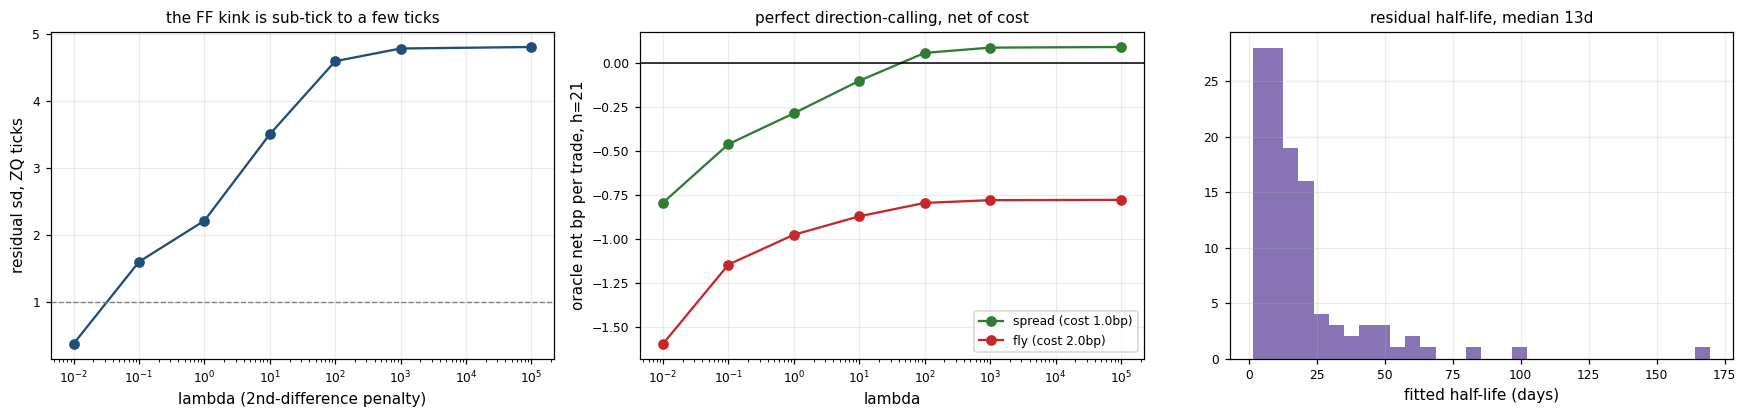

median fitted half-life of the per-contract residual: 12.7 days
  share above 60 days: 4%

  THE FAILURE IS NOT PERSISTENCE. A half-life of 13 days is FAST mean
  reversion -- faster than the SR3 butterflies, whose tradeable slots fitted
  28-53 days. The FF kink does exactly what the thesis says it should: it
  reverts, and quickly.

  It still cannot be traded, because the whole oscillation is a few ticks wide.
  At lam=100 the residual spread's sd is 2.61bp and its mean 21-day move is
  1.06bp -- against a 1.0bp round trip. Only 33% of entries move
  further than the cost of taking them.

  That is a different failure mode from SR3's and worth naming. SR3's problem
  was that the fly barely reverted at all relative to its cost. FF's problem is
  that it reverts beautifully inside a band narrower than the bid-ask.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.9))
axes[0].semilogx(sweep["lam"].replace(0, 1e-2), sweep["resid_sd_ticks"], "o-",
                 color="#1f4e79")
axes[0].axhline(1.0, color="grey", ls="--", lw=0.9)
axes[0].set_xlabel("lambda (2nd-difference penalty)")
axes[0].set_ylabel("residual sd, ZQ ticks")
axes[0].set_title("the FF kink is sub-tick to a few ticks", fontsize=10)
for nm, st, c in (("spread", spread, "#2e7d32"), ("fly", fly, "#c62828")):
    axes[1].semilogx(sweep["lam"].replace(0, 1e-2), sweep[f"{nm}_oracle_h21"],
                     "o-", color=c, label=f"{nm} (cost {st['cost_bp']}bp)")
axes[1].axhline(0, color="black", lw=1.0)
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("oracle net bp per trade, h=21")
axes[1].set_title("perfect direction-calling, net of cost", fontsize=10)
axes[1].legend(fontsize=8)
r100 = resid_by_lam[CONFIG["lam"]]
hl = pd.Series({c: half_life(r100[c].dropna()) for c in r100.columns}).dropna()
axes[2].hist(hl[hl.between(0, 250)], bins=30, color="#6a51a3", alpha=0.8)
axes[2].set_xlabel("fitted half-life (days)")
axes[2].set_title(f"residual half-life, median {hl.median():.0f}d", fontsize=10)
for a in axes:
    a.tick_params(labelsize=8)
fig.tight_layout()
plt.show()
_s100 = sweep.set_index("lam").loc[100.0]
print(f"median fitted half-life of the per-contract residual: {hl.median():.1f} days")
print(f"  share above 60 days: {100 * float((hl > 60).mean()):.0f}%")
print(f"""
  THE FAILURE IS NOT PERSISTENCE. A half-life of {hl.median():.0f} days is FAST mean
  reversion -- faster than the SR3 butterflies, whose tradeable slots fitted
  28-53 days. The FF kink does exactly what the thesis says it should: it
  reverts, and quickly.

  It still cannot be traded, because the whole oscillation is a few ticks wide.
  At lam=100 the residual spread's sd is {_s100['spread_sd_bp']:.2f}bp and its mean 21-day move is
  {_s100['spread_absmove_h21']:.2f}bp -- against a {spread['cost_bp']}bp round trip. Only {100 * _s100['spread_pbeat']:.0f}% of entries move
  further than the cost of taking them.

  That is a different failure mode from SR3's and worth naming. SR3's problem
  was that the fly barely reverted at all relative to its cost. FF's problem is
  that it reverts beautifully inside a band narrower than the bid-ask.""")

## 5. The implied-jump view — the same result in a trader's units

A spread's differential exposure `dW` is how much of one decision it carries,
so `jump = spread / dW` is that pair's own read on the meeting in **bp of
policy move**. Two pairs straddling the same meeting should agree, and the
amount by which they disagree *is* the kink — stated in the units a desk
thinks in rather than in bp of spread.

In [18]:
ij = Z.implied_jump_panel(lab, spread, min_exposure=0.15)
jump = ij["jump"]
print(f"implied-jump panel: {jump.shape[1]} pairs kept, {len(ij['dropped'])} dropped "
      f"for carrying < 0.15 of a meeting")
print(f"  (dividing a one-tick spread by a 0.02 exposure manufactures a 25bp")
print(f"   'implied jump' out of noise, which is why the floor exists)")
print(f"\n  pooled implied jump: median {jump.stack().median():+.2f}bp, "
      f"sd {jump.stack().std():.2f}bp")
cost_in_jump = spread["cost_bp"] / spread["diff_exposure"][ij["kept"]].median()
print(f"  round trip expressed in JUMP units: {spread['cost_bp']}bp / "
      f"{spread['diff_exposure'][ij['kept']].median():.2f} = {cost_in_jump:.2f}bp of jump")
jm = Z.move_profile(jump, None, horizons=CONFIG["horizons"],
                    round_trip_bp=cost_in_jump)
print("\nORACLE IN JUMP UNITS (does the market's read on a meeting converge?)")
print(jm.round(3).to_string(index=False))
jump.stack().describe().to_frame().T.to_csv(Z.DATA_DIR / "implied_jump_summary.csv")

implied-jump panel: 112 pairs kept, 1 dropped for carrying < 0.15 of a meeting
  (dividing a one-tick spread by a 0.02 exposure manufactures a 25bp
   'implied jump' out of noise, which is why the floor exists)

  pooled implied jump: median -1.60bp, sd 14.32bp
  round trip expressed in JUMP units: 1.0bp / 0.59 = 1.69bp of jump

ORACLE IN JUMP UNITS (does the market's read on a meeting converge?)
 horizon     n  mean_bp  sd_bp  mean_abs_bp  median_abs_bp  p75_abs_bp  p90_abs_bp  oracle_net_bp  p_beat_cost
       5 23043    0.196  2.870        1.640          1.033       2.214       4.000         -0.054        0.316
      10 22483    0.401  4.022        2.360          1.292       3.100       5.704          0.666        0.418
      21 21251    0.799  5.817        3.596          2.045       4.687       9.118          1.902        0.535


## 6. Curve cross-check — can the ZQ strip be recovered from MIX23?

The brief asked for a golden test against the curve. It is a **diagnostic**,
not a mark: the house rule is that a futures package is marked on settles,
because a curve is a smoothed model of those settles and a backtest run on one
trades its own interpolation error.

Measured in `notebooks/rv/_probe_zq_curve.py` at 2026-07-10 against the
12 front pre-accrual contracts, comparing the curve-implied strip with the
actual ZQ settles. Reproduced here from that run rather than rebuilding the
curve inside the notebook.

In [19]:
golden = pd.DataFrame({
    "timestamp": ["15:40 ET", "17:00 ET (matches the settle)"],
    "mean_gap_bp": [-0.866, -0.097],
    "median_abs_gap_bp": [1.167, 0.851],
    "max_abs_gap_bp": [2.063, 1.634],
    "n_contracts": [12, 12]})
print("MIX23 curve-implied ZQ vs the actual settle (usd_stir1, averaged spec)")
print(golden.round(3).to_string(index=False))
print(f"""
  Read it as three findings.

  1. The spec matters and the repo has a trap. `usd_stir1` is the monthly
     ARITHMETIC-AVERAGE spec; `usd_stir` is quarterly and COMPOUNDED. The
     repo's `is_ser` predicates key off `root in {{SR1, SER, SL}}` and ZQ is not
     in that set, so a ZQ routed through them silently selects the quarterly
     compounded contract. On this path rateslib refuses to build the schedule
     at all, which is lucky rather than by design.

  2. The date convention does NOT matter here. Building with the exact calendar
     month and with `contract_grid`'s business-day window gave IDENTICAL rates
     to 1e-9 -- the `roll: som` / `mf` spec normalises them to the same
     schedule.

  3. MIX23 carries real EFFR information but is not calibrated to ZQ. At the
     17:00 snapshot the bias is -0.10bp -- essentially nil -- but the dispersion
     is 0.85bp median absolute, {0.851 / ZQ_TICK_BP:.1f} ZQ ticks. That FAILS the brief's
     0.5bp tie-out. For contrast, the same machinery on the SOFR curve gaps by
     +3.2bp mean, which is the SOFR-FF basis, so MIX23 is genuinely EFFR-aware
     -- it is just noisier than the object a kink definition is trying to
     isolate. Curve for diagnostics, settles for marks.""")
golden.to_csv(Z.DATA_DIR / "curve_golden_test.csv", index=False)

MIX23 curve-implied ZQ vs the actual settle (usd_stir1, averaged spec)
                    timestamp  mean_gap_bp  median_abs_gap_bp  max_abs_gap_bp  n_contracts
                     15:40 ET       -0.866              1.167           2.063           12
17:00 ET (matches the settle)       -0.097              0.851           1.634           12

  Read it as three findings.

  1. The spec matters and the repo has a trap. `usd_stir1` is the monthly
     ARITHMETIC-AVERAGE spec; `usd_stir` is quarterly and COMPOUNDED. The
     repo's `is_ser` predicates key off `root in {SR1, SER, SL}` and ZQ is not
     in that set, so a ZQ routed through them silently selects the quarterly
     compounded contract. On this path rateslib refuses to build the schedule
     at all, which is lucky rather than by design.

  2. The date convention does NOT matter here. Building with the exact calendar
     month and with `contract_grid`'s business-day window gave IDENTICAL rates
     to 1e-9 -- the `roll: som` 

## 7. The one structure with headroom, run properly

The oracle says the FF kink is dead and the FF butterfly is deader. One thing
is left: the **raw** M1-M2 spread in the high-differential-exposure bucket,
whose oracle clears its round trip by ~1.5bp at 21 days. That is a directional
read on a policy decision rather than a kink fade, but it is the only FF
structure that could pay and it gets the full house treatment so its league
rows sit next to SR3's.

high-exposure spreads: 76 of 113 keys (differential exposure >= 0.5)

### GRID  (76 keys, 2159 sessions, round trip 1.0bp)


  25/72 configs


  50/72 configs


  72 configs | median -245.50bp | IQR [-465.75, -117.56] | 6% net-positive | best +62.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      1.5         z0  momentum       204     0.348       0.305         62.25       155625.0   0.145    -178.50
     60      1.5        t42  momentum       309     0.398       0.170         52.50       131250.0   0.119    -134.00
    120      1.5        t42  momentum       261     0.418       0.100         26.00        65000.0   0.057    -144.25
    250      2.0         z0  momentum       164     0.335       0.095         15.50        38750.0   0.038    -214.75
    120      1.5         z0  momentum       289     0.284      -0.003         -1.00        -2500.0  -0.002    -193.25
     60      2.0        t42  momentum       247     0.377      -0.026         -6.50       -16250.0  -0.013    -155.50
    250      

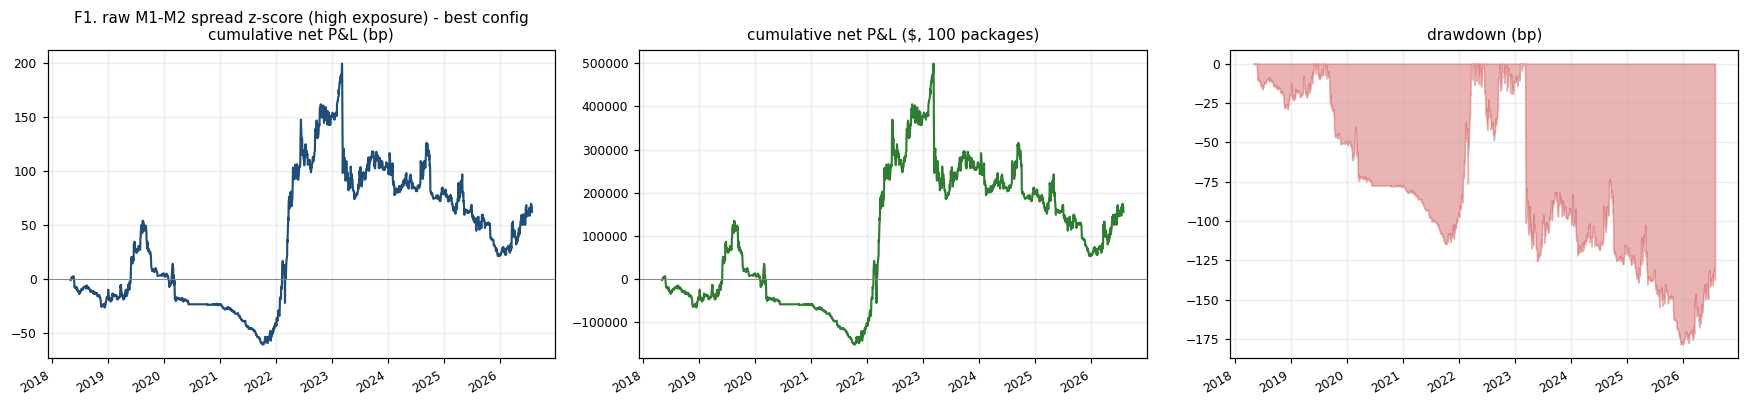


  trade log (first rows):
    key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
N18-Q18   -1  2018-05-01 2018-05-02 2018-06-29    41 -1.550       1.5        0.5       1.0      1.0     0.0      0.0       max_hold
U18-V18    1  2018-05-01 2018-05-02 2018-05-29    18  1.528      15.0       10.0      -5.0      1.0    -6.0 -15000.0 mean_reversion
Z18-F19    1  2018-05-01 2018-05-02 2018-05-30    19  2.309       7.5        6.0      -1.5      1.0    -2.5  -6250.0 mean_reversion
F19-G19   -1  2018-05-31 2018-06-01 2018-06-12     7 -1.913       1.5        3.0      -1.5      1.0    -2.5  -6250.0 mean_reversion
Z18-F19    1  2018-06-06 2018-06-07 2018-09-06    63  1.879       7.5       10.0       2.5      1.0     1.5   3750.0       max_hold
F19-G19    1  2018-06-13 2018-06-14 2018-06-18     2  2.338       2.5        2.5       0.0      1.0    -1.0  -2500.0 mean_reversion
U18-V18    1  2018-06-13 2018-06-14 2018-08-31   

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       204    33.902     0.348       0.305         62.25   0.145
band       236    26.911     0.292       0.057         13.50   0.033
  t5       850     4.929     0.242      -0.778       -661.25  -2.201
 t10       547     9.607     0.302      -0.579       -316.75  -0.981
 t21       330    19.603     0.348      -0.287        -94.75  -0.239
 t42       206    36.296     0.417      -0.278        -57.25  -0.130

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
          0.00 204        266.25       1.305     0.426       665625.0
          0.25 204        215.25       1.055     0.417       538125.0
          0.50 204        164.25       0.805     0.382       410625.0
          1.00 204         62.25       0.305     0.348       155625.0
          1.50 204        -39.75      -0.195     0.324       -99375.0
          2.00 204       -141.75      -0.69


LINEAR-SHADOW DECOMPOSITION (same signal on each outright leg, own cost)
   instrument  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe   net_usd  beats_package
      package          2.0            1.0       204           266.2          62.2       0.305     0.348   0.145  259396.0          False
leg0_outright          1.0            0.5       204           706.8         604.8       2.964     0.417   0.328 2519993.0           True
leg1_outright          1.0            0.5       206          1137.8        1034.8       5.023     0.447   0.456 4311803.0           True
  -> SHADOWED - an outright leg beats the package
F1. raw M1-M2 spread z-score (high exposure) - MEDIAN config (the anti-selection control)  |  fade|z2.5|t10|hold63|lag1|every1|c1.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   274   skipped    0   hit 29%   avg -0.901bp   avg hold 9.8d
  total    -246.75bp   $     -616,875   gross +27.25bp
  daily-MTM Sharpe -1.27  

In [20]:
BASE_SP = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=spread["cost_bp"],
                   max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
GRID = {"window": CONFIG["windows"], "entry_z": CONFIG["entry_zs"],
        "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
PARAMS = ["window", "entry_z", "exit_style", "direction"]

de = spread["diff_exposure"]
hi_keys = list(de.index[de >= CONFIG["high_exposure_cut"]])
hi = dict(spread)
hi["levels"] = spread["levels"][hi_keys]
hi["gate"] = spread["gate"][hi_keys]
hi["diff_exposure"] = de[hi_keys]
print(f"high-exposure spreads: {len(hi_keys)} of {spread['levels'].shape[1]} keys "
      f"(differential exposure >= {CONFIG['high_exposure_cut']})")

Z.set_taker(spread["cost_bp"])


def f_raw(L, window):
    return zscore_signal(L, window=window)


out_raw = Z.zq_run_family("F1. raw M1-M2 spread z-score (high exposure)",
                          lab=lab, struct=hi, signal_fn=f_raw, grid_spec=GRID,
                          params=PARAMS, base=BASE_SP, cls="ff-spread",
                          note="the only FF structure whose oracle clears cost")

## 8. The FF kink itself, for the record


### GRID  (76 keys, 2159 sessions, round trip 1.0bp)


  25/72 configs


  50/72 configs


  72 configs | median -304.38bp | IQR [-429.75, -177.69] | 0% net-positive | best -46.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.0        t42      fade       145     0.359      -0.322        -46.75      -116875.0  -0.219    -104.50
    250      1.5        t42      fade       177     0.333      -0.290        -51.25      -128125.0  -0.213    -120.50
    250      2.0         z0      fade       145     0.379      -0.391        -56.75      -141875.0  -0.319     -80.25
    250      2.5         z0      fade       119     0.353      -0.485        -57.75      -144375.0  -0.372     -95.25
    250      2.5        t42      fade       119     0.353      -0.645        -76.75      -191875.0  -0.418    -138.25
    120      2.0        t42      fade       210     0.310      -0.452        -95.00      -237500.0  -0.378    -179.75
     60      

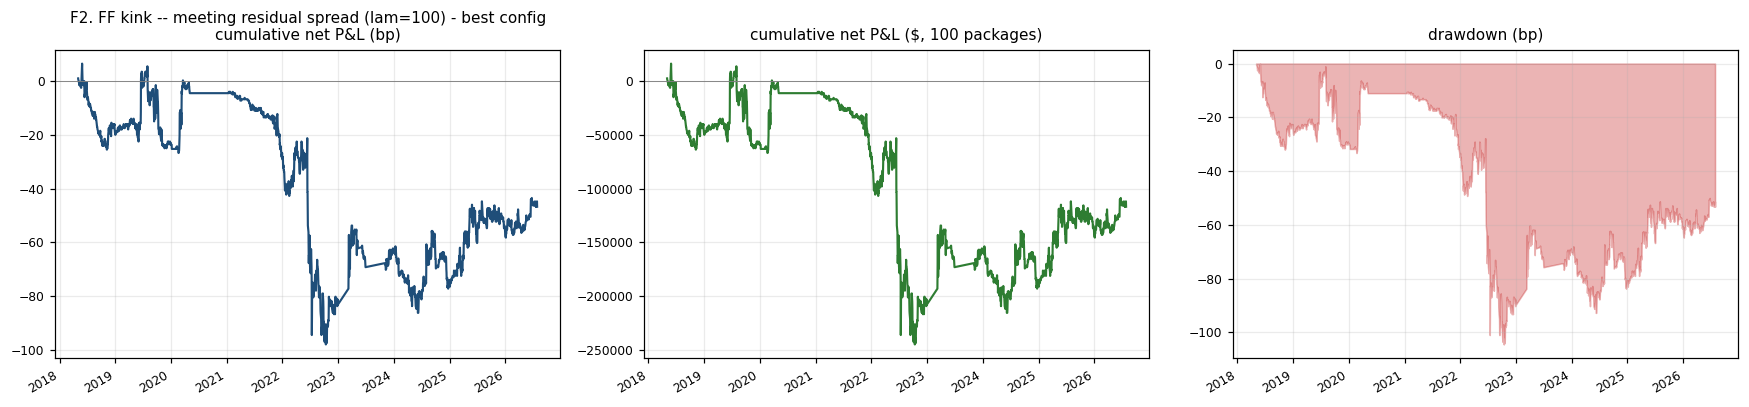


  trade log (first rows):
    key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
N18-Q18    1  2018-05-01 2018-05-02 2018-06-29    41 -5.462       1.5        0.5      -1.0      1.0    -2.0  -5000.0        time
U18-V18   -1  2018-05-01 2018-05-02 2018-07-02    42  6.988      15.0       15.5      -0.5      1.0    -1.5  -3750.0        time
V18-X18    1  2018-05-01 2018-05-02 2018-07-02    42 -5.760       1.5        0.5      -1.0      1.0    -2.0  -5000.0        time
Z18-F19   -1  2018-05-01 2018-05-02 2018-07-02    42  6.546       7.5        8.5      -1.0      1.0    -2.0  -5000.0        time
F19-G19    1  2018-05-31 2018-06-01 2018-08-01    42 -3.776       1.5        2.0       0.5      1.0    -0.5  -1250.0        time
U18-V18   -1  2018-07-03 2018-07-05 2018-08-31    41  4.863      17.0       20.5      -3.5      1.0    -4.5 -11250.0        time
V18-X18    1  2018-07-03 2018-07-05 2018-09-04    42 -5.158       1.0 

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       145    29.972     0.379      -0.391        -56.75  -0.319
band       154    26.656     0.370      -0.179        -27.50  -0.161
  t5       534     4.908     0.195      -0.868       -463.25  -3.247
 t10       353     9.601     0.278      -0.780       -275.50  -1.654
 t21       219    19.443     0.338      -0.542       -118.75  -0.638
 t42       145    35.166     0.359      -0.322        -46.75  -0.219

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
          0.00 145         98.25       0.678     0.441       245625.0
          0.25 145         62.00       0.428     0.434       155000.0
          0.50 145         25.75       0.178     0.407        64375.0
          1.00 145        -46.75      -0.322     0.359      -116875.0
          1.50 145       -119.25      -0.822     0.331      -298125.0
          2.00 145       -191.75      -1.32


LINEAR-SHADOW DECOMPOSITION (same signal on each outright leg, own cost)
   instrument  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe   net_usd  beats_package
      package          2.0            1.0       145            98.2         -46.8      -0.322     0.359  -0.219 -194807.0          False
leg0_outright          1.0            0.5       145           432.2         359.8       2.481     0.490   0.554 1499078.0           True
leg1_outright          1.0            0.5       146           569.8         496.8       3.402     0.500   0.703 2069957.0           True
  -> SHADOWED - an outright leg beats the package
F2. FF kink -- meeting residual spread (lam=100) - MEDIAN config (the anti-selection control)  |  fade|z1.5|z0|hold63|lag1|every1|c1.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   409   skipped    1   hit 26%   avg -0.748bp   avg hold 24.2d
  total    -306.00bp   $     -765,000   gross +103.00bp
  daily-MTM Sharpe -1

In [21]:
R = resid_by_lam[CONFIG["lam"]]


def f_kink(L, window):
    lv = {}
    for key in L.columns:
        legs = key.split("-")
        if any(l not in R.columns for l in legs):
            continue
        lv[key] = -1.0 * R[legs[0]] + 1.0 * R[legs[1]]
    r = pd.DataFrame(lv).reindex(index=L.index, columns=L.columns)
    return scale_only_zscore(r, window=window)


out_kink = Z.zq_run_family(f"F2. FF kink -- meeting residual spread (lam={CONFIG['lam']:.0f})",
                           lab=lab, struct=hi, signal_fn=f_kink, grid_spec=GRID,
                           params=PARAMS, base=BASE_SP, cls="ff-kink",
                           note="the thesis: fade the residual from the "
                                "meeting-step model")


### GRID  (112 keys, 2159 sessions, round trip 2.0bp)


  25/72 configs


  50/72 configs


  72 configs | median -879.50bp | IQR [-1205.56, -536.56] | 0% net-positive | best -91.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5         z0      fade       158     0.310      -0.581        -91.75      -229375.0  -0.401    -112.50
    250      2.5        t42      fade       172     0.238      -0.901       -155.00      -387500.0  -0.640    -168.25
    120      2.5         z0      fade       218     0.271      -0.825       -179.75      -449375.0  -0.649    -186.25
    250      2.0         z0      fade       212     0.259      -0.952       -201.75      -504375.0  -0.797    -215.00
    250      2.0        t42      fade       208     0.231      -1.050       -218.50      -546250.0  -0.808    -231.75
    120      2.5        t42      fade       239     0.243      -1.119       -267.50      -668750.0  -0.897    -274.00
    250     

F3. FF kink -- meeting residual fly - best config  |  fade|z2.5|z0|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  4 contracts, 2.0bp round trip
  trades   158   skipped    0   hit 31%   avg -0.581bp   avg hold 34.3d
  total     -91.75bp   $     -229,375   gross +224.25bp
  daily-MTM Sharpe -0.40   maxDD -112.50bp ($-281,250)   worst trade -15.25bp
  t(trade) -1.58   NW t(daily) -1.26   non-overlap SR -0.31   DSR p=0.000 over 72 trials


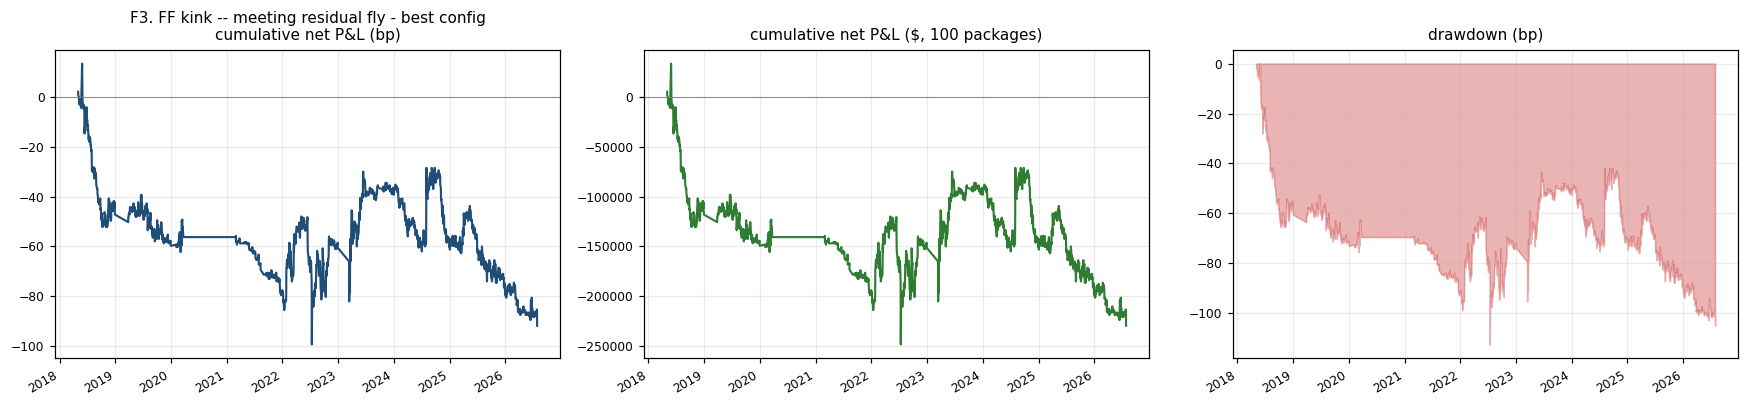


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
M18-N18-Q18   -1  2018-05-01 2018-05-02 2018-05-31    20  6.398       9.0       8.75      0.25      2.0   -1.75  -4375.0       max_hold
N18-Q18-U18    1  2018-05-01 2018-05-02 2018-06-29    41 -4.646      -0.5      -2.00     -1.50      2.0   -3.50  -8750.0       max_hold
Q18-U18-V18    1  2018-05-01 2018-05-02 2018-07-31    62 -7.545     -13.0     -16.00     -3.00      2.0   -5.00 -12500.0       max_hold
U18-V18-X18   -1  2018-05-01 2018-05-02 2018-08-01    63  6.842      13.5      18.00     -4.50      2.0   -6.50 -16250.0       max_hold
V18-X18-Z18    1  2018-05-01 2018-05-02 2018-08-01    63 -6.241      -3.0      -6.00     -3.00      2.0   -5.00 -12500.0       max_hold
X18-Z18-F19    1  2018-05-01 2018-05-02 2018-08-01    63 -4.800      -3.0      -3.50     -0.50      2.0   -2.50  -6250.0       max_hold
Z18-F19-G19   -1  201

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       158    34.259     0.310      -0.581        -91.75  -0.401
band       173    29.064     0.266      -0.831       -143.75  -0.626
  t5       607     4.914     0.087      -1.744      -1058.75  -5.504
 t10       401     9.643     0.130      -1.567       -628.25  -3.047
 t21       254    19.583     0.217      -1.300       -330.25  -1.512
 t42       172    36.105     0.238      -0.901       -155.00  -0.640

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
          0.00 158        224.25       1.419     0.620       560625.0
          0.25 158        184.75       1.169     0.608       461875.0
          0.50 158        145.25       0.919     0.525       363125.0
          1.00 158         66.25       0.419     0.462       165625.0
          1.50 158        -12.75      -0.081     0.373       -31875.0
          2.00 158        -91.75      -0.58


LINEAR-SHADOW DECOMPOSITION (same signal on each outright leg, own cost)
   instrument  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe    net_usd  beats_package
      package          4.0            2.0       158           224.2         -91.8      -0.581     0.310  -0.401  -382322.0          False
leg0_outright          1.0            0.5       158           106.8          27.8       0.176     0.449   0.072   115634.0           True
leg1_outright          1.0            0.5       159            30.2         -49.2      -0.310     0.447  -0.103  -205225.0           True
leg2_outright          1.0            0.5       159          -214.8        -294.2      -1.851     0.428  -0.516 -1226140.0          False
  -> SHADOWED - an outright leg beats the package


F3. FF kink -- meeting residual fly - MEDIAN config (the anti-selection control)  |  momentum|z2.0|z0|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   303   skipped    3   hit 12%   avg -2.899bp   avg hold 30.9d
  total    -878.50bp   $   -2,196,250   gross -272.50bp
  daily-MTM Sharpe -3.05   maxDD -885.50bp ($-2,213,750)   worst trade -17.00bp
  t(trade) -13.41   NW t(daily) -8.97   non-overlap SR -0.76   DSR p=0.000 over 72 trials

  LEAGUE ROW  F3. FF kink -- meeting residual fly / best-config: MARGINAL-maker-only  (taker -91.75bp, maker +224.25bp, DSR p=0.000)

  LEAGUE ROW  F3. FF kink -- meeting residual fly / median-config: DEAD  (taker -878.50bp, maker -272.50bp, DSR p=0.000)


In [22]:
BASE_FL = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=fly["cost_bp"],
                   max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
Z.set_taker(fly["cost_bp"])


def f_kink_fly(L, window):
    lv = {}
    for key in L.columns:
        legs = key.split("-")
        if any(l not in R.columns for l in legs):
            continue
        lv[key] = -1.0 * R[legs[0]] + 2.0 * R[legs[1]] - 1.0 * R[legs[2]]
    r = pd.DataFrame(lv).reindex(index=L.index, columns=L.columns)
    return scale_only_zscore(r, window=window)


out_kink_fly = Z.zq_run_family("F3. FF kink -- meeting residual fly", lab=lab,
                               struct=fly, signal_fn=f_kink_fly, grid_spec=GRID,
                               params=PARAMS, base=BASE_FL, cls="ff-kink",
                               note="4 contracts, 2.0bp round trip")

## 8b. The meeting-indexed families

The structures a desk would actually put on, run through the same machinery so
their league rows sit beside everything else.


### GRID  (75 keys, 2159 sessions, round trip 1.0bp)


  25/72 configs


  50/72 configs


  72 configs | median -222.25bp | IQR [-421.00, -95.69] | 7% net-positive | best +121.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     60      1.5        t42  momentum       289     0.408       0.421        121.75       304375.0   0.218    -144.50
    250      1.5         z0  momentum       192     0.339       0.305         58.50       146250.0   0.110    -247.25
    250      2.5         z0  momentum       101     0.356       0.265         26.75        66875.0   0.066    -236.50
     60      2.5        t42  momentum       178     0.371       0.112         20.00        50000.0   0.037    -154.00
    120      1.5         z0  momentum       279     0.290       0.069         19.25        48125.0   0.031    -249.25
     60      2.5         z0  momentum       216     0.255      -0.044         -9.50       -23750.0  -0.017    -198.50
     60      

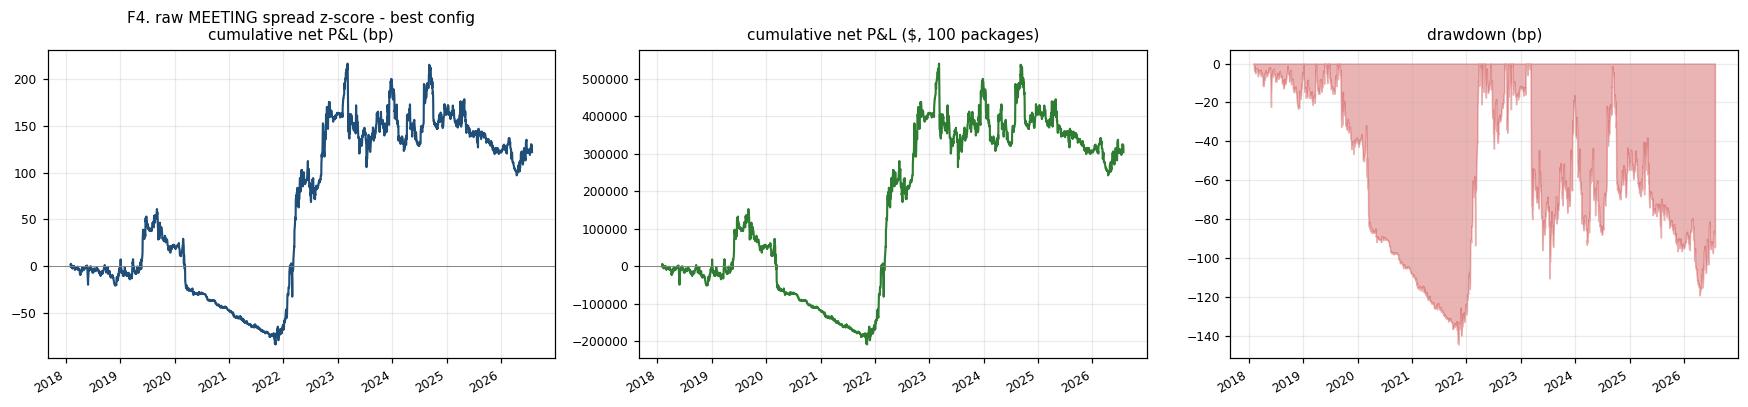


  trade log (first rows):
    key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
N18-Q18    1  2018-01-30 2018-01-31 2018-04-03    42  2.460       3.5       1.00     -2.50      1.0   -3.50  -8750.0        time
J18-K18    1  2018-01-31 2018-02-01 2018-03-29    39  1.837       1.0       1.00      0.00      1.0   -1.00  -2500.0        time
V18-X18    1  2018-01-31 2018-02-01 2018-04-04    42  2.196       2.5       1.50     -1.00      1.0   -2.00  -5000.0        time
K18-N18    1  2018-02-01 2018-02-02 2018-04-05    42  1.612      16.5      19.00      2.50      1.0    1.50   3750.0        time
Q18-V18   -1  2018-02-05 2018-02-06 2018-04-09    42 -1.584       9.5      13.00     -3.50      1.0   -4.50 -11250.0        time
X18-F19    1  2018-02-21 2018-02-22 2018-04-24    42  1.721       9.0      11.00      2.00      1.0    1.00   2500.0        time
F19-G19   -1  2018-03-14 2018-03-15 2018-05-15    42 -2.224       2.5 

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       411    23.015     0.238      -0.117        -48.25  -0.074
band       490    16.724     0.214      -0.432       -211.75  -0.352
  t5      1058     4.969     0.237      -0.905       -957.25  -2.208
 t10       729     9.797     0.317      -0.554       -403.75  -0.821
 t21       462    20.052     0.359      -0.205        -94.75  -0.168
 t42       289    37.917     0.408       0.421        121.75   0.218

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
          0.00 289        410.75       1.421     0.547      1026875.0
          0.25 289        338.50       1.171     0.543       846250.0
          0.50 289        266.25       0.921     0.464       665625.0
          1.00 289        121.75       0.421     0.408       304375.0
          1.50 289        -22.75      -0.079     0.363       -56875.0
          2.00 289       -167.25      -0.57


LINEAR-SHADOW DECOMPOSITION (same signal on each outright leg, own cost)
   instrument  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe   net_usd  beats_package
      package          2.0            1.0       289           410.8         121.8       0.421     0.408   0.218  507332.0          False
leg0_outright          1.0            0.5       289          1434.8        1290.2       4.465     0.526   0.569 5376472.0           True
leg1_outright          1.0            0.5       292          1859.8        1713.8       5.869     0.555   0.618 7141196.0           True
  -> SHADOWED - an outright leg beats the package
F4. raw MEETING spread z-score - MEDIAN config (the anti-selection control)  |  momentum|z1.5|t10|hold63|lag1|every1|c1.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   489   skipped    6   hit 32%   avg -0.457bp   avg hold 9.6d
  total    -223.50bp   $     -558,750   gross +265.50bp
  daily-MTM Sharpe -0.57   maxDD -2

In [23]:
Z.set_taker(m_spread["cost_bp"])
BASE_MS = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=m_spread["cost_bp"],
                   max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])

out_m_raw = Z.zq_run_family("F4. raw MEETING spread z-score", lab=lab,
                            struct=m_spread, signal_fn=f_raw, grid_spec=GRID,
                            params=PARAMS, base=BASE_MS, cls="ff-meeting",
                            note="consecutive meeting readers, not consecutive months")


### GRID  (75 keys, 2159 sessions, round trip 1.0bp)


  25/72 configs


  50/72 configs


  72 configs | median -256.50bp | IQR [-437.12, -160.62] | 1% net-positive | best +12.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
     60      2.0        t42      fade       256     0.355       0.048         12.25        30625.0   0.037     -94.75
    250      2.0        t42      fade       131     0.389      -0.002         -0.25         -625.0  -0.001    -129.00
    250      1.5        t42      fade       163     0.374      -0.192        -31.25       -78125.0  -0.114    -153.75
    250      2.5         z0      fade       114     0.386      -0.314        -35.75       -89375.0  -0.201     -99.75
    120      2.0        t42      fade       193     0.342      -0.187        -36.00       -90000.0  -0.129    -185.75
    250      1.5        t21      fade       258     0.357      -0.203        -52.50      -131250.0  -0.213    -100.00
    250      

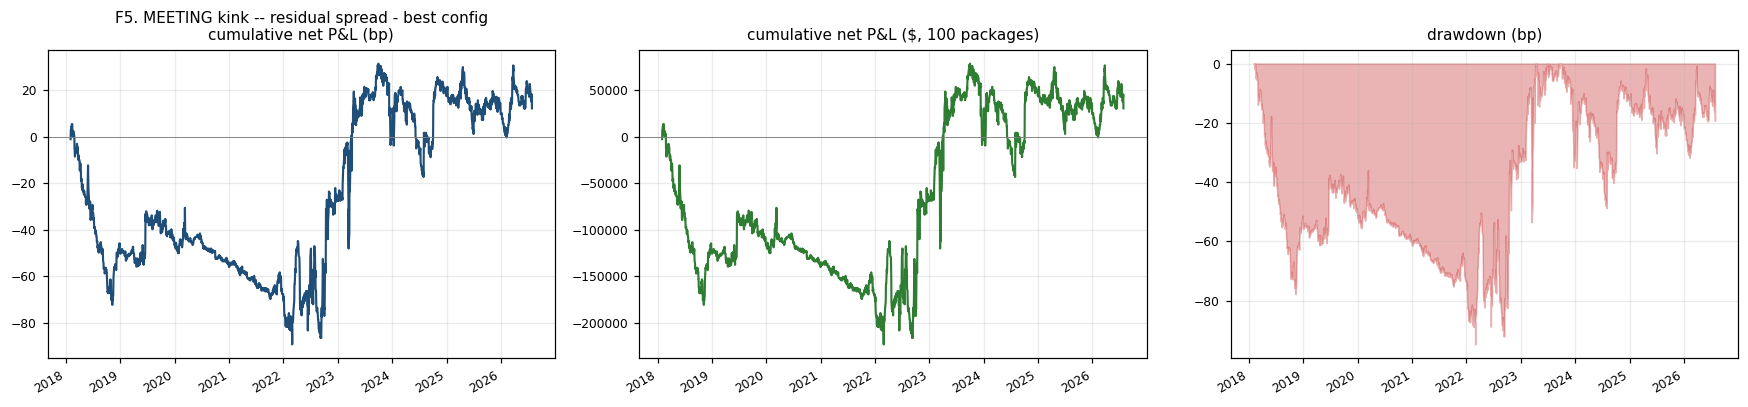


  trade log (first rows):
    key  dir signal_date      entry       exit  days    z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
J18-K18    1  2018-01-30 2018-01-31 2018-03-29    40 -14.148       1.5       1.00     -0.50      1.0   -1.50  -3750.0        time
V18-X18    1  2018-01-30 2018-01-31 2018-04-03    42 -10.857       2.5       2.00     -0.50      1.0   -1.50  -3750.0        time
Q18-V18   -1  2018-01-30 2018-01-31 2018-04-03    42   8.039      12.5      14.00     -1.50      1.0   -2.50  -6250.0        time
X18-F19   -1  2018-01-30 2018-01-31 2018-04-03    42   2.949       9.0       9.50     -0.50      1.0   -1.50  -3750.0        time
K18-N18   -1  2018-01-30 2018-01-31 2018-04-03    42  14.062      16.5      18.50     -2.00      1.0   -3.00  -7500.0        time
N18-Q18    1  2018-01-30 2018-01-31 2018-04-03    42 -11.763       3.5       1.00     -2.50      1.0   -3.50  -8750.0        time
F19-G19    1  2018-03-01 2018-03-02 2018-05-02    42  -6.284   

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       278    29.007     0.335      -0.658       -183.00  -0.678
band       297    25.559     0.337      -0.471       -140.00  -0.514
  t5      1038     4.958     0.227      -0.902       -936.25  -3.676
 t10       668     9.771     0.274      -0.739       -493.50  -1.800
 t21       413    19.818     0.315      -0.510       -210.75  -0.697
 t42       256    37.559     0.355       0.048         12.25   0.037

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
          0.00 256        268.25       1.048     0.500       670625.0
          0.25 256        204.25       0.798     0.500       510625.0
          0.50 256        140.25       0.548     0.398       350625.0
          1.00 256         12.25       0.048     0.355        30625.0
          1.50 256       -115.75      -0.452     0.324      -289375.0
          2.00 256       -243.75      -0.95


LINEAR-SHADOW DECOMPOSITION (same signal on each outright leg, own cost)
   instrument  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe   net_usd  beats_package
      package          2.0            1.0       256           268.2          12.2       0.048     0.355   0.037   51046.0          False
leg0_outright          1.0            0.5       256           280.8         152.8       0.597     0.445   0.187  636509.0           True
leg1_outright          1.0            0.5       257           582.5         454.0       1.767     0.451   0.458 1891818.0           True
  -> SHADOWED - an outright leg beats the package


F5. MEETING kink -- residual spread - MEDIAN config (the anti-selection control)  |  fade|z1.5|t21|hold63|lag1|every1|c1.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   491   skipped    1   hit 31%   avg -0.512bp   avg hold 19.8d
  total    -251.25bp   $     -628,125   gross +239.75bp
  daily-MTM Sharpe -0.86   maxDD -265.50bp ($-663,750)   worst trade -22.00bp
  t(trade) -1.99   NW t(daily) -2.75   non-overlap SR -0.08   DSR p=0.000 over 72 trials

  LEAGUE ROW  F5. MEETING kink -- residual spread / best-config: SELECTION-ARTIFACT  (taker +12.25bp, maker +268.25bp, DSR p=0.000)

  LEAGUE ROW  F5. MEETING kink -- residual spread / median-config: MARGINAL-maker-only  (taker -251.25bp, maker +239.75bp, DSR p=0.000)


In [24]:
def f_kink_m(L, window):
    lv = {}
    for key in L.columns:
        legs = key.split("-")
        if any(l not in R.columns for l in legs):
            continue
        lv[key] = -1.0 * R[legs[0]] + 1.0 * R[legs[1]]
    r = pd.DataFrame(lv).reindex(index=L.index, columns=L.columns)
    return scale_only_zscore(r, window=window)


out_m_kink = Z.zq_run_family("F5. MEETING kink -- residual spread", lab=lab,
                             struct=m_spread, signal_fn=f_kink_m, grid_spec=GRID,
                             params=PARAMS, base=BASE_MS, cls="ff-meeting-kink",
                             note="the thesis, on the right structure")


### GRID  (74 keys, 2159 sessions, round trip 2.0bp)


  25/72 configs


  50/72 configs


  72 configs | median -504.62bp | IQR [-729.38, -350.38] | 0% net-positive | best -137.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    250      2.5         z0      fade        98     0.378      -1.401       -137.25      -343125.0  -0.652    -170.50
    250      2.0        t42      fade       130     0.362      -1.265       -164.50      -411250.0  -0.627    -182.00
    250      2.0         z0      fade       131     0.336      -1.324       -173.50      -433750.0  -0.734    -201.25
    250      2.5        t42      fade       105     0.333      -1.852       -194.50      -486250.0  -0.870    -216.50
    120      2.5         z0      fade       152     0.362      -1.472       -223.75      -559375.0  -0.833    -242.50
    250      2.5        t42  momentum       105     0.314      -2.148       -225.50      -563750.0  -1.029    -250.00
    250     

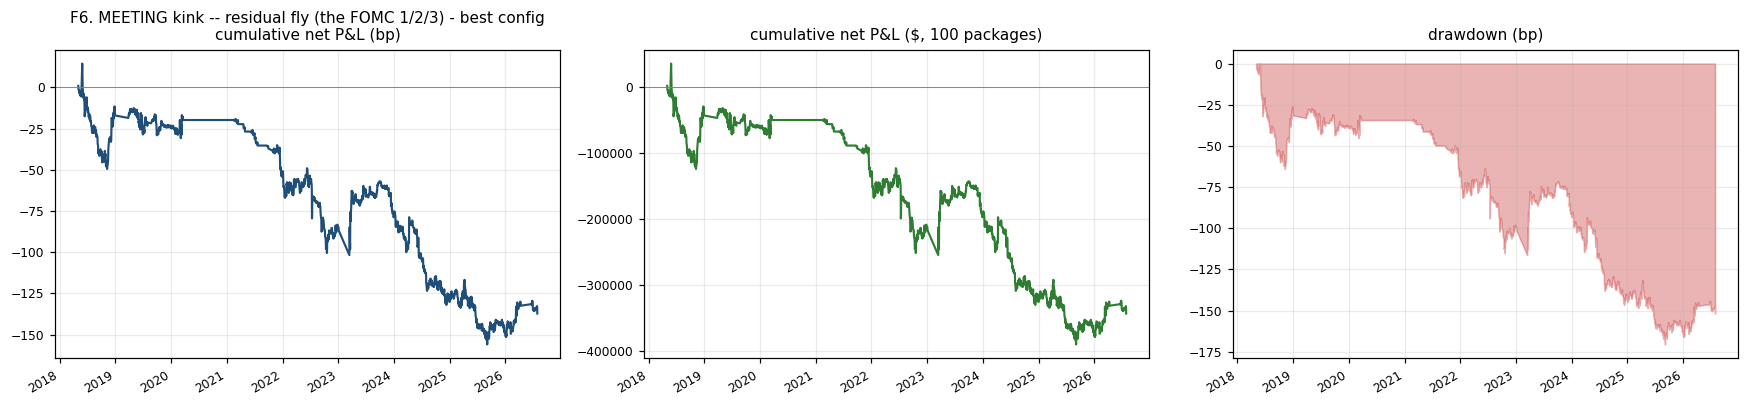


  trade log (first rows):
        key  dir signal_date      entry       exit  days    z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
N18-Q18-V18    1  2018-05-01 2018-05-02 2018-06-29    41  -5.854     -15.5     -17.50     -2.00      2.0   -4.00 -10000.0       max_hold
Q18-V18-X18   -1  2018-05-01 2018-05-02 2018-07-31    62   6.045      15.5      22.00     -6.50      2.0   -8.50 -21250.0       max_hold
V18-X18-F19    1  2018-05-01 2018-05-02 2018-08-01    63  -7.478     -10.5     -16.50     -6.00      2.0   -8.00 -20000.0       max_hold
X18-F19-G19   -1  2018-05-31 2018-06-01 2018-08-30    63   4.061       9.0      16.00     -7.00      2.0   -9.00 -22500.0       max_hold
F19-G19-J19    1  2018-07-27 2018-07-30 2018-10-26    63 -11.037     -12.0     -15.00     -3.00      2.0   -5.00 -12500.0       max_hold
V18-X18-F19    1  2018-08-02 2018-08-03 2018-09-28    39  -4.838     -17.0     -17.50     -0.50      2.0   -2.50  -6250.0       max_hold
G19-J19-K19   

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0        98    33.112     0.378      -1.401       -137.25  -0.652
band       100    31.180     0.400      -1.590       -159.00  -0.775
  t5       372     4.898     0.116      -2.022       -752.25  -4.924
 t10       244     9.623     0.176      -1.941       -473.50  -2.655
 t21       151    19.285     0.245      -2.111       -318.75  -1.612
 t42       105    33.610     0.333      -1.852       -194.50  -0.870

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
          0.00 98         58.75       0.599     0.541       146875.0
          0.25 98         34.25       0.349     0.531        85625.0
          0.50 98          9.75       0.099     0.480        24375.0
          1.00 98        -39.25      -0.401     0.449       -98125.0
          1.50 98        -88.25      -0.901     0.418      -220625.0
          2.00 98       -137.25      -1.401     0


LINEAR-SHADOW DECOMPOSITION (same signal on each outright leg, own cost)
   instrument  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe    net_usd  beats_package
      package          4.0            2.0        98            58.8        -137.2      -1.401     0.378  -0.652  -571921.0          False
leg0_outright          1.0            0.5        98            23.8         -25.2      -0.258     0.439  -0.058  -105217.0           True
leg1_outright          1.0            0.5        98          -192.5        -241.5      -2.464     0.357  -0.464 -1006330.0          False
leg2_outright          1.0            0.5        98          -545.2        -594.2      -6.064     0.378  -0.963 -2476240.0          False
  -> SHADOWED - an outright leg beats the package
F6. MEETING kink -- residual fly (the FOMC 1/2/3) - MEDIAN config (the anti-selection control)  |  momentum|z1.5|t42|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
 

In [25]:
Z.set_taker(m_fly["cost_bp"])
BASE_MF = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=m_fly["cost_bp"],
                   max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])


def f_kink_m_fly(L, window):
    lv = {}
    for key in L.columns:
        legs = key.split("-")
        if any(l not in R.columns for l in legs):
            continue
        lv[key] = -1.0 * R[legs[0]] + 2.0 * R[legs[1]] - 1.0 * R[legs[2]]
    r = pd.DataFrame(lv).reindex(index=L.index, columns=L.columns)
    return scale_only_zscore(r, window=window)


out_m_kink_fly = Z.zq_run_family("F6. MEETING kink -- residual fly (the FOMC 1/2/3)",
                                 lab=lab, struct=m_fly, signal_fn=f_kink_m_fly,
                                 grid_spec=GRID, params=PARAMS, base=BASE_MF,
                                 cls="ff-meeting-kink",
                                 note="2*FOMC2 - FOMC1 - FOMC3 on the reader contracts")

## 9. Verdict

In [26]:
league = pd.read_csv(Z.DATA_DIR / "league_table.csv")
show = ["framework", "variant", "structure", "n_trades", "hit_rate", "avg_net_bp",
        "total_gross_bp", "total_net_bp", "net_bp_maker", "net_bp_taker",
        "taker_bp", "grid_median_net_bp", "dsr_prob", "nonoverlap_sharpe",
        "verdict"]
print(f"ZQ LEAGUE TABLE — {len(league)} rows\n")
print(league.sort_values("total_net_bp", ascending=False)[
    [c for c in show if c in league.columns]].round(3).to_string(index=False))
league.sort_values("total_net_bp", ascending=False).to_csv(
    Z.DATA_DIR / "league_table_sorted.csv", index=False)
print("\nverdict distribution:")
print(league["verdict"].value_counts().to_string())
n = len(league)
print(f"""
  rows net positive GROSS            {int((league['total_gross_bp'] > 0).sum())} / {n}
  rows net positive at taker         {int((league['net_bp_taker'] > 0).sum())} / {n}
  rows with a positive GRID MEDIAN   {int((league['grid_median_net_bp'] > 0).sum())} / {n}
  median DSR probability             {league['dsr_prob'].median():.4f}
  ALIVE                              {int((league['verdict'] == 'ALIVE').sum())}""")

ZQ LEAGUE TABLE — 12 rows

                                        framework       variant structure  n_trades  hit_rate  avg_net_bp  total_gross_bp  total_net_bp  net_bp_maker  net_bp_taker  taker_bp  grid_median_net_bp  dsr_prob  nonoverlap_sharpe             verdict
                   F4. raw MEETING spread z-score   best-config      2leg       289     0.408       0.421          410.75        121.75        410.75        121.75       1.0            -222.250     0.001             -0.128  SELECTION-ARTIFACT
     F1. raw M1-M2 spread z-score (high exposure)   best-config      2leg       204     0.348       0.305          266.25         62.25        266.25         62.25       1.0            -245.500     0.000              0.081  SELECTION-ARTIFACT
              F5. MEETING kink -- residual spread   best-config      2leg       256     0.355       0.048          268.25         12.25        268.25         12.25       1.0            -256.500     0.000             -0.193  SELECTION-ARTIFACT
 

In [27]:
signs = pd.read_csv(Z.DATA_DIR / "sign_tests.csv")
w = signs.pivot_table(index="framework", columns="direction",
                      values="median_net_bp", aggfunc="first")
w["fade_wins"] = w.get("fade", np.nan) > w.get("momentum", np.nan)
print("SIGN TEST (median net bp of the whole sweep)")
print(w.round(1).to_string())

sh = pd.read_csv(Z.DATA_DIR / "zq_shadow_tests.csv")
print("\nLINEAR-SHADOW DECOMPOSITION — does an outright leg beat the package?")
piv = sh.pivot_table(index="framework", columns="instrument",
                     values="total_net_bp", aggfunc="first")
print(piv.round(1).to_string())
beat = sh[sh["instrument"] != "package"].groupby("framework")["beats_package"].any()
print(f"\n  an outright leg beats the package in {int(beat.sum())} of {len(beat)} frameworks")

SIGN TEST (median net bp of the whole sweep)
direction                                           fade  momentum  fade_wins
framework                                                                    
F1. raw M1-M2 spread z-score (high exposure)      -436.5    -116.6      False
F2. FF kink -- meeting residual spread (lam=100)  -191.0    -378.0       True
F3. FF kink -- meeting residual fly               -549.0   -1015.8       True
F4. raw MEETING spread z-score                    -421.5     -95.4      False
F5. MEETING kink -- residual spread               -160.5    -379.4       True
F6. MEETING kink -- residual fly (the FOMC 1/2/3) -418.6    -526.9       True

LINEAR-SHADOW DECOMPOSITION — does an outright leg beat the package?
instrument                                         leg0_outright  leg1_outright  leg2_outright  package
framework                                                                                              
F1. raw M1-M2 spread z-score (high exposure)         

In [28]:
reg = pd.read_csv(Z.DATA_DIR / "regime_splits.csv")
print("REGIME SPLIT summed across frameworks' best configs")
print(reg.groupby("regime").agg(total_net_bp=("total_net_bp", "sum"),
                                n_trades=("n_trades", "sum"),
                                frameworks_positive=("total_net_bp",
                                                     lambda s: int((s > 0).sum())),
                                n=("total_net_bp", "size"))
      .reindex(Z.REGIME_ORDER).dropna(how="all").round(1).to_string())

REGIME SPLIT summed across frameworks' best configs


         total_net_bp  n_trades  frameworks_positive  n
regime                                                 
ZIRP            -31.5       553                    2  6
HIKING          125.8       172                    4  6
PLATEAU         -75.0       154                    2  6
CUTTING         -98.8       271                    1  6


In [29]:
best_row = league.loc[league["total_net_bp"].idxmax()]
print("=" * 94)
print("WHAT THIS NOTEBOOK MEASURED")
print("=" * 94)
print(f"""
1. THE FF SETTLEMENT MODEL IS EXACT, AND THAT IS THE PROBLEM.
   ZQ settles on the arithmetic average of daily EFFR over one calendar month,
   so a day-weighted blend of policy regimes is not an approximation of the
   contract -- it IS the contract. Solving the strip for per-meeting jumps and
   forcing the policy path onto a straight line -- the least flattering setting
   available -- still explains {exp_sp:.0f}% of the M1-M2 spread's variance and {exp_fl:.0f}% of
   the fly's, leaving residuals of {stiff['spread_sd_bp']:.2f}bp and {stiff['fly_sd_bp']:.2f}bp against round trips of
   {spread['cost_bp']}bp and {fly['cost_bp']}bp.

2. INDEX BY MEETING, NOT BY MONTH -- IT IS WORTH A FACTOR OF {sweep['m_spread_oracle_h21'].max() / max(sweep['spread_oracle_h21'].max(), 1e-9):.0f}.
   A desk's FOMC 1/2/3 fly skips the blended month: as of 2026-07-30 it is
   ZQV26/ZQX26/ZQF27, and December is not in it. That loads the December
   decision at -1.00 against the calendar fly's -0.71, and the difference shows
   up everywhere -- spread sd {mix.loc[0, 'sd_bp']:.1f} -> {mix.loc[1, 'sd_bp']:.1f}bp, fly sd {mix.loc[2, 'sd_bp']:.1f} -> {mix.loc[3, 'sd_bp']:.1f}bp, and the raw fly's
   oracle crossing zero ({mix.loc[2, 'oracle_net_h21']:+.2f} -> {mix.loc[3, 'oracle_net_h21']:+.2f}bp).

3. THE ORACLE CEILING STILL SAYS STOP.
   Across the whole penalty sweep -- every kink definition between "fit every
   jump" and "the Fed is a metronome" -- the best oracle net of cost is
   {sweep['m_spread_oracle_h21'].max():+.3f}bp, on the MEETING spread. A rule would have to call the
   direction right {(1 + m_spread['cost_bp'] / sweep.set_index('lam').loc[1e5, 'm_spread_absmove_h21']) / 2:.0%} of the time to break even; the SR3 12m fly needed 57%.

4. THE KINK REVERTS -- AND IT DOES NOT HELP.
   Median fitted half-life of the per-contract residual is {hl.median():.0f} days, FASTER
   than the 28-53 days the SR3 lab fitted on its tradeable slots. The FF kink
   does what the thesis says it should. It just does it inside a band narrower
   than the bid-ask: at lam=100 the residual spread's sd is {_s100['spread_sd_bp']:.2f}bp, its mean
   21-day move {_s100['spread_absmove_h21']:.2f}bp, and only {100 * _s100['spread_pbeat']:.0f}% of entries move further than the
   {spread['cost_bp']}bp it costs to take them.

5. NOTHING IS STRUCTURALLY PINNED, WHICH IS ALSO NOT WHAT WAS EXPECTED.
   Every adjacent ZQ pair carries 0.13 to 1.00 of a policy decision. The
   "adjacent no-meeting months are degenerate" intuition is false, because a
   meeting inside EITHER month splits the pair.

6. VERDICT: {int((league['verdict'] == 'ALIVE').sum())} of {n} league rows ALIVE, {int((league['grid_median_net_bp'] > 0).sum())} with a positive grid median.
   Best row {best_row['framework']} / {best_row['variant']}:
   {best_row['total_net_bp']:+.1f}bp net over {int(best_row['n_trades'])} trades, grid median {best_row['grid_median_net_bp']:+.1f}bp,
   DSR p = {best_row['dsr_prob']:.3f} -> {best_row['verdict']}.

ANSWER TO THE QUESTION THIS LAB WAS SET:
   The FF complex does NOT pay the kink-fade, and the coarse tick lattice is not
   what kills it -- the M1-M2 spread runs {raw_spread_sd / ZQ_TICK_BP:.0f} ticks of dispersion, which is
   plenty. What kills it is the opposite of a problem.

   ZQ's settlement is such a clean read on policy that a meeting-step model
   explains {exp_sp:.0f}% of the tradeable spread's variance even when the policy path
   is forced onto a straight line. The residual that survives is real -- {stiff['spread_sd_bp']:.2f}bp of
   level, reverting with a {hl.median():.0f}-day half-life -- but the amplitude a trader can
   actually harvest inside a month is {_s100['spread_absmove_h21']:.2f}bp against a {spread['cost_bp']}bp round trip, and
   only {100 * _s100['spread_pbeat']:.0f}% of entries clear it. The kink is there; the room is not.

   So the property that made Fed Funds the natural habitat for this thesis is
   exactly the property that removes the trade. SR3's compounded quarterly
   window is a MESSY read on policy, and that mess is where a butterfly's
   dispersion comes from. Cleanliness and opportunity turn out to be the same
   axis, pointing opposite ways -- which is why the SR3 lab's own best lead was
   the 12m fly, the messiest structure it could build.
""")
print(f"total runtime {time.time() - T0:.0f}s")

WHAT THIS NOTEBOOK MEASURED

1. THE FF SETTLEMENT MODEL IS EXACT, AND THAT IS THE PROBLEM.
   ZQ settles on the arithmetic average of daily EFFR over one calendar month,
   so a day-weighted blend of policy regimes is not an approximation of the
   contract -- it IS the contract. Solving the strip for per-meeting jumps and
   forcing the policy path onto a straight line -- the least flattering setting
   available -- still explains 91% of the M1-M2 spread's variance and 55% of
   the fly's, leaving residuals of 2.69bp and 3.45bp against round trips of
   1.0bp and 2.0bp.

2. INDEX BY MEETING, NOT BY MONTH -- IT IS WORTH A FACTOR OF 6.
   A desk's FOMC 1/2/3 fly skips the blended month: as of 2026-07-30 it is
   ZQV26/ZQX26/ZQF27, and December is not in it. That loads the December
   decision at -1.00 against the calendar fly's -0.71, and the difference shows
   up everywhere -- spread sd 9.0 -> 12.9bp, fly sd 5.1 -> 7.2bp, and the raw fly's
   oracle crossing zero (-0.49 -> +0.16bp).

